In [1]:
! pip install bnlp_toolkit

In [2]:
!rm -rf /kaggle/working/*

In [3]:
# ============================================================
# Cell: Import Libraries
# ============================================================

import os
import re
import random
import warnings
import textwrap
from collections import defaultdict

import numpy as np
import pandas as pd
import tensorflow as tf
import gradio as gr

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties

from tqdm.notebook import tqdm
from bnlp import CleanText, BengaliCorpus, NLTKTokenizer
from gensim.models import FastText

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Conv1D,
    BatchNormalization,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D,
    GlobalAveragePooling1D,
    Concatenate,
    Dense,
    Dropout
)

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
%matplotlib inline

TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [4]:
# ============================================================
# Cell 3: Reproducibility Configuration
# ============================================================

# Define a single random seed for reproducible experiments.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configure deterministic TensorFlow operations where possible.
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [5]:
df=pd.read_excel("/kaggle/input/datasets/mizan116/suspicious-bengali-text-slang/suspicious Bangla text.xlsx")

In [6]:
df.head()

,Text,binary_label
0,১ থেকে ১০০ এর মধ্যে আপনার প্রিয় নম্বর কি? এর উ...,0
1,ওএমজি ওএমজি ওএমজি হ্যাঁ হ্যাঁ এটি ... এটি নিখু...,0
2,এই ছুটির দিনটি একটি বোর্ডে পেরেক করা একজনকে উদ...,1
3,সেই রাজাকার বাহিনী আর জঙ্গী বাহিনী বঙ্গবন্ধু ক...,1
4,হ্যাঁ আমি বালিশগুলি লাইভ জার্নাল জারক রোটেশনগু...,1


In [7]:
corpus = BengaliCorpus()
print(corpus.stopwords)
print(corpus.punctuations)
print(corpus.letters)
print(corpus.digits)
print(corpus.vowels)

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

In [8]:
tqdm.pandas()

cleaner = CleanText(
    fix_unicode=True,
    unicode_norm=True,
    unicode_norm_form="NFKC",
    remove_url=True,
    remove_email=True,
    remove_emoji=True,
    remove_number=True,
    remove_digits=True,
    remove_punct=True,
    replace_with_url="",
    replace_with_email="",
    replace_with_number="",
    replace_with_digit="",
    replace_with_punct=""
)

df["Text"] = (df["Text"].astype(str).progress_apply(cleaner).str.replace(r"\s+", " ", regex=True).str.strip())

stop_words = corpus.stopwords

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df["Text"] = df["Text"].progress_apply(remove_stopwords)

  0%|          | 0/43389 [00:00<?, ?it/s]

  0%|          | 0/43389 [00:00<?, ?it/s]

In [9]:
has_english = df["Text"].str.contains(r'[a-zA-Z]', na=False).any()
print("Contains English letters:", has_english)

Contains English letters: True


In [10]:
tqdm.pandas()

def remove_all_english(text):
    text = str(text)
    text = re.sub(r'[a-zA-Z]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Text'] = df['Text'].progress_apply(remove_all_english)

  0%|          | 0/43389 [00:00<?, ?it/s]

In [11]:
has_english = df["Text"].str.contains(r'[a-zA-Z]', na=False).any()
print("Contains English letters:", has_english)

Contains English letters: False


In [12]:
df.head()

,Text,binary_label
0,প্রিয় নম্বর মার্চে এক এপ্রিলে আরেকরকম,0
1,ওএমজি ওএমজি ওএমজি হ্যাঁ হ্যাঁ নিখুঁত দুর্দান্ত...,0
2,ছুটির দিনটি বোর্ডে পেরেক একজনকে উদযাপন চাই সম্...,1
3,রাজাকার বাহিনী জঙ্গী বাহিনী বঙ্গবন্ধু কন্যা শে...,1
4,হ্যাঁ বালিশগুলি লাইভ জার্নাল জারক রোটেশনগুলি প...,1


In [13]:
df.shape

(43389, 2)

In [14]:
df.isnull().sum()

Text            0
binary_label    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(6774)

In [16]:
text_duplicates = df.duplicated(subset=['Text']).sum()
print(f"Number of duplicate texts: {text_duplicates}")

Number of duplicate texts: 6823


In [17]:
# Drop duplicates based on the 'Text' column and update the dataframe
df.drop_duplicates(subset=['Text'], keep='first', inplace=True)

# Verify they are gone
print("Remaining duplicates:", df.duplicated(subset=['Text']).sum())

Remaining duplicates: 0


In [18]:
df.shape

(36566, 2)

In [19]:
# ============================================================
# Cell 4: Experiment Configuration
# ============================================================

# Path to the dataset.
DATA_PATH = "/kaggle/input/your-dataset-folder/your_dataset.csv"

# Dataset column names.
TEXT_COLUMN = "Text"
LABEL_COLUMN = "binary_label"

# Data split configuration.
TEST_SIZE = 0.10
VALID_SIZE = 0.10

# Vocabulary and sequence configuration.
MAX_VOCAB_SIZE = 30000
MAX_SEQUENCE_LENGTH = 150

# FastText configuration.
FASTTEXT_VECTOR_SIZE = 300
FASTTEXT_WINDOW = 5
FASTTEXT_MIN_COUNT = 2
FASTTEXT_EPOCHS = 15

# Training configuration.
BATCH_SIZE = 64
EPOCHS = 100

# Model configuration.
EMBEDDING_TRAINABLE = True

# Model checkpoint path.
BEST_MODEL_PATH = "/kaggle/working/best_fasttext_cnn_bilstm.keras"

print("Configuration loaded successfully.")

Configuration loaded successfully.


In [20]:
# ============================================================
# Cell Class Distribution Analysis
# ============================================================

class_counts = (df[LABEL_COLUMN].value_counts().sort_index())

print("Class distribution:")
print(class_counts)

print("\nClass percentages:")
print((class_counts / len(df) * 100).round(2))

Class distribution:
binary_label
0    22530
1    14036
Name: count, dtype: int64

Class percentages:
binary_label
0    61.61
1    38.39
Name: count, dtype: float64


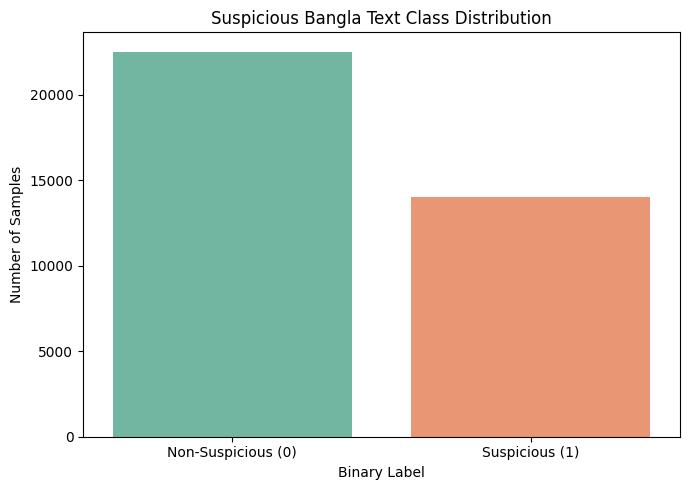

In [21]:
# ============================================================
# Cell  Visualize Class Distribution
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df,x=LABEL_COLUMN,palette="Set2")

plt.title("Suspicious Bangla Text Class Distribution")
plt.xlabel("Binary Label")
plt.ylabel("Number of Samples")
plt.xticks([0, 1],["Non-Suspicious (0)", "Suspicious (1)"])

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Cell Stratified Train/Validation/Test Split
# ============================================================

X = df[TEXT_COLUMN].values
y = df[LABEL_COLUMN].values

# First split into training and temporary sets.
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=TEST_SIZE + VALID_SIZE,stratify=y,
    random_state=SEED)

# Calculate validation proportion relative to the temporary set.
relative_valid_size = VALID_SIZE / (TEST_SIZE + VALID_SIZE)

# Split temporary data into validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=TEST_SIZE / (TEST_SIZE + VALID_SIZE),
    stratify=y_temp,
    random_state=SEED
)

print("Training samples:  ", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:      ", len(X_test))

Training samples:   29252
Validation samples: 3657
Test samples:       3657


In [23]:
# ============================================================
# Cell  Verify Class Distribution Across Splits
# ============================================================

def show_distribution(name, labels):
    counts = pd.Series(labels).value_counts().sort_index()
    percentages = (
        counts / len(labels) * 100
    ).round(2)

    print(f"\n{name}")
    print("-" * 40)

    for label in [0, 1]:
        print(f"Class {label}: " f"{counts.get(label, 0)} " f"({percentages.get(label, 0):.2f}%)")


show_distribution("Training Set", y_train)
show_distribution("Validation Set", y_val)
show_distribution("Test Set", y_test)


Training Set
----------------------------------------
Class 0: 18024 (61.62%)
Class 1: 11228 (38.38%)

Validation Set
----------------------------------------
Class 0: 2253 (61.61%)
Class 1: 1404 (38.39%)

Test Set
----------------------------------------
Class 0: 2253 (61.61%)
Class 1: 1404 (38.39%)


In [24]:
# ============================================================
# Cell Prepare FastText Training Corpus
# ============================================================

# Tokenize the training texts using whitespace.
fasttext_sentences = [text.split() for text in X_train]

# Remove empty sentences.
fasttext_sentences = [tokens for tokens in fasttext_sentences if len(tokens) > 0]

print("FastText training sentences:", len(fasttext_sentences))
print("Example tokenized sentence:")
print(fasttext_sentences[0][:20])

FastText training sentences: 29251
Example tokenized sentence:
['আহামরি', 'যেটা', 'আমারআপনার', 'লাগবে', 'জীবনে', 'এফর্টের', 'পিছে', 'চিন্তাটা', 'স্যালুট']


In [25]:
# ===========================================================
# Cell Train FastText Embeddings
# ============================================================

# Train a Skip-Gram FastText model on the training corpus.
fasttext_model = FastText(
    sentences=fasttext_sentences,
    vector_size=FASTTEXT_VECTOR_SIZE,
    window=FASTTEXT_WINDOW,
    min_count=FASTTEXT_MIN_COUNT,
    sg=1,
    workers=max(1, os.cpu_count() - 1),
    epochs=FASTTEXT_EPOCHS,
    seed=SEED
)

print("FastText training completed.")
print("Vocabulary size:",len(fasttext_model.wv))
print("Embedding dimension:",fasttext_model.vector_size)

FastText training completed.
Vocabulary size: 20329
Embedding dimension: 300


In [26]:
sample_word = "বাংলাদেশ"

# FastText can generate vectors for many unseen words
# using subword information.
sample_vector = fasttext_model.wv.get_vector(sample_word)

print("Word:", sample_word)
print("Vector shape:", sample_vector.shape)
print("First 10 values:")
print(sample_vector[:10])

Word: বাংলাদেশ
Vector shape: (300,)
First 10 values:
[ 0.23764054  0.2700214  -0.05079568 -0.56992614  0.10768076  0.12526764
 -0.10551258  0.07972372  0.16559595  0.35852215]


In [27]:
# ============================================================
# Cell Create Keras Text Vectorization Layer
# ============================================================

# Create the vocabulary mapping using only training text.
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    standardize=None,
    split="whitespace"
)

# Adapt vocabulary using training data only.
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(256))

# Retrieve the vocabulary.
vocabulary = vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocabulary))
print("First 20 vocabulary tokens:")
print(vocabulary[:20])

I0000 00:00:1786896123.547515    3432 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Vocabulary size: 30000
First 20 vocabulary tokens:
['', '[UNK]', np.str_('ভাল'), np.str_('একটা'), np.str_('ঘৃণা'), np.str_('সাথে'), np.str_('ভালো'), np.str_('নাটক'), np.str_('কথা'), np.str_('এক'), np.str_('হা'), np.str_('ভাই'), np.str_('মানুষ'), np.str_('সুন্দর'), np.str_('সময়'), np.str_('আপনাকে'), np.str_('তোর'), np.str_('অভিশাপ'), np.str_('চাই'), np.str_('বড়')]


In [28]:
# 1. Find the top 5 most similar words
print(f"Words most similar to '{sample_word}':")
similar_words = fasttext_model.wv.most_similar(sample_word, topn=10)

for word, score in similar_words:
    print(f"{word}: {score:.4f}")

Words most similar to 'বাংলাদেশ':
বাংলাদেশই: 0.9937
বাংলাদেশর: 0.9936
বাংলাদেশী: 0.9845
বাংলাদেশীর: 0.9841
বাংলাদেশটা: 0.9840
বাংলাদেশির: 0.9814
বাংলাদেশেও: 0.9812
বাংলাদেশি: 0.9808
বাংলাদেশীরা: 0.9792
বাংলাদেশেই: 0.9770


In [29]:
# 2. Check similarity between two words
word2 = "ঢাকা" # Dhaka
similarity_score = fasttext_model.wv.similarity(sample_word, word2)

print(f"Similarity between '{sample_word}' and '{word2}': {similarity_score:.4f}")

Similarity between 'বাংলাদেশ' and 'ঢাকা': 0.3680


In [30]:
# 3. Find the word that doesn't belong
word_list = ["বাংলাদেশ", "ভারত", "আম"] # Bangladesh, India, Mango
odd_word = fasttext_model.wv.doesnt_match(word_list)

print(f"The odd word out in {word_list} is: '{odd_word}'")

The odd word out in ['বাংলাদেশ', 'ভারত', 'আম'] is: 'আম'


In [31]:
# 4. Word Analogies
# Example logic: Bangladesh - Dhaka + New Delhi = ? (Should theoretically output India)
result = fasttext_model.wv.most_similar(positive=['বাংলাদেশ', 'দিল্লি'], negative=['ঢাকা'], topn=1)

print(f"Analogy result: {result[0][0]} with a score of {result[0][1]:.4f}")

Analogy result: নাবাংলাদেশ with a score of 0.7684


In [32]:
# Select a meaningful word from your vocabulary
target_word = "ভালো"

# Get the top 10 most similar words
top_10_similar = fasttext_model.wv.most_similar(target_word, topn=10)

print(f"Top 10 words most similar to '{target_word}':\n")
print("-" * 35)

# Loop through and print the results nicely
for i, (word, score) in enumerate(top_10_similar, 1):
    print(f"{i:2}. {word:<15} (Score: {score:.4f})")

Top 10 words most similar to 'ভালো':

-----------------------------------
 1. ভালোই           (Score: 0.9134)
 2. ভালোর           (Score: 0.9109)
 3. ভালোনা          (Score: 0.8784)
 4. ভালোটা          (Score: 0.8763)
 5. ভালও            (Score: 0.8604)
 6. ভালর            (Score: 0.8531)
 7. ভালোলাগা        (Score: 0.8525)
 8. ভালই            (Score: 0.8501)
 9. ভালোলাগে        (Score: 0.8415)
10. ভালোকিছু        (Score: 0.8357)


In [33]:
# Load and Register Bangla Font
font_path = '/kaggle/input/datasets/programminghero009/bangla-font/kalpurush.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size'] = 10

print("Bangla font loaded:", font_prop.get_name())

Bangla font loaded: Kalpurush


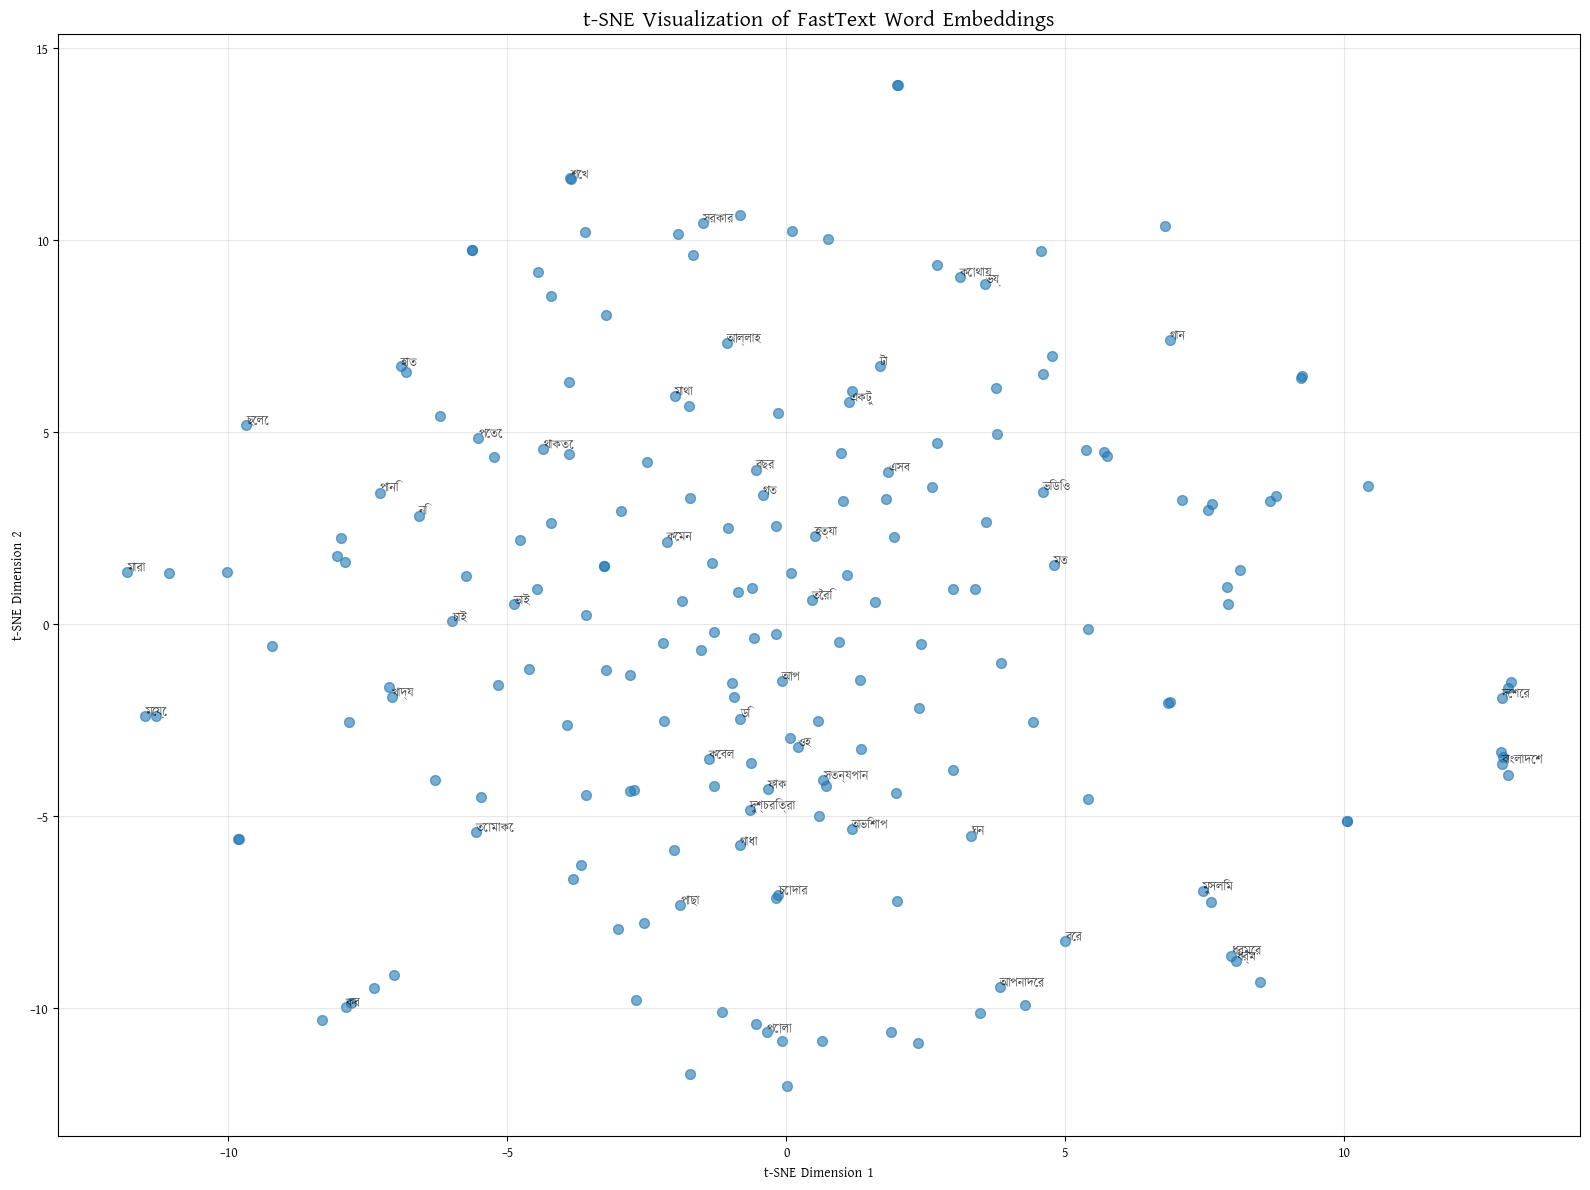

In [34]:
# Select words to visualize (most frequent + some interesting ones)
word_list = list(fasttext_model.wv.index_to_key)[:200]  # Top 200 words

# Get vectors for selected words
vectors = np.array([fasttext_model.wv[word] for word in word_list])

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(16, 12))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.6, s=50)

# Annotate a subset of words
annotate_count = min(50, len(word_list))
indices = np.random.choice(len(word_list), annotate_count, replace=False)
for i in indices:
    plt.annotate(word_list[i], (vectors_2d[i, 0], vectors_2d[i, 1]), 
                 fontsize=9, alpha=0.7)

plt.title('t-SNE Visualization of FastText Word Embeddings', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

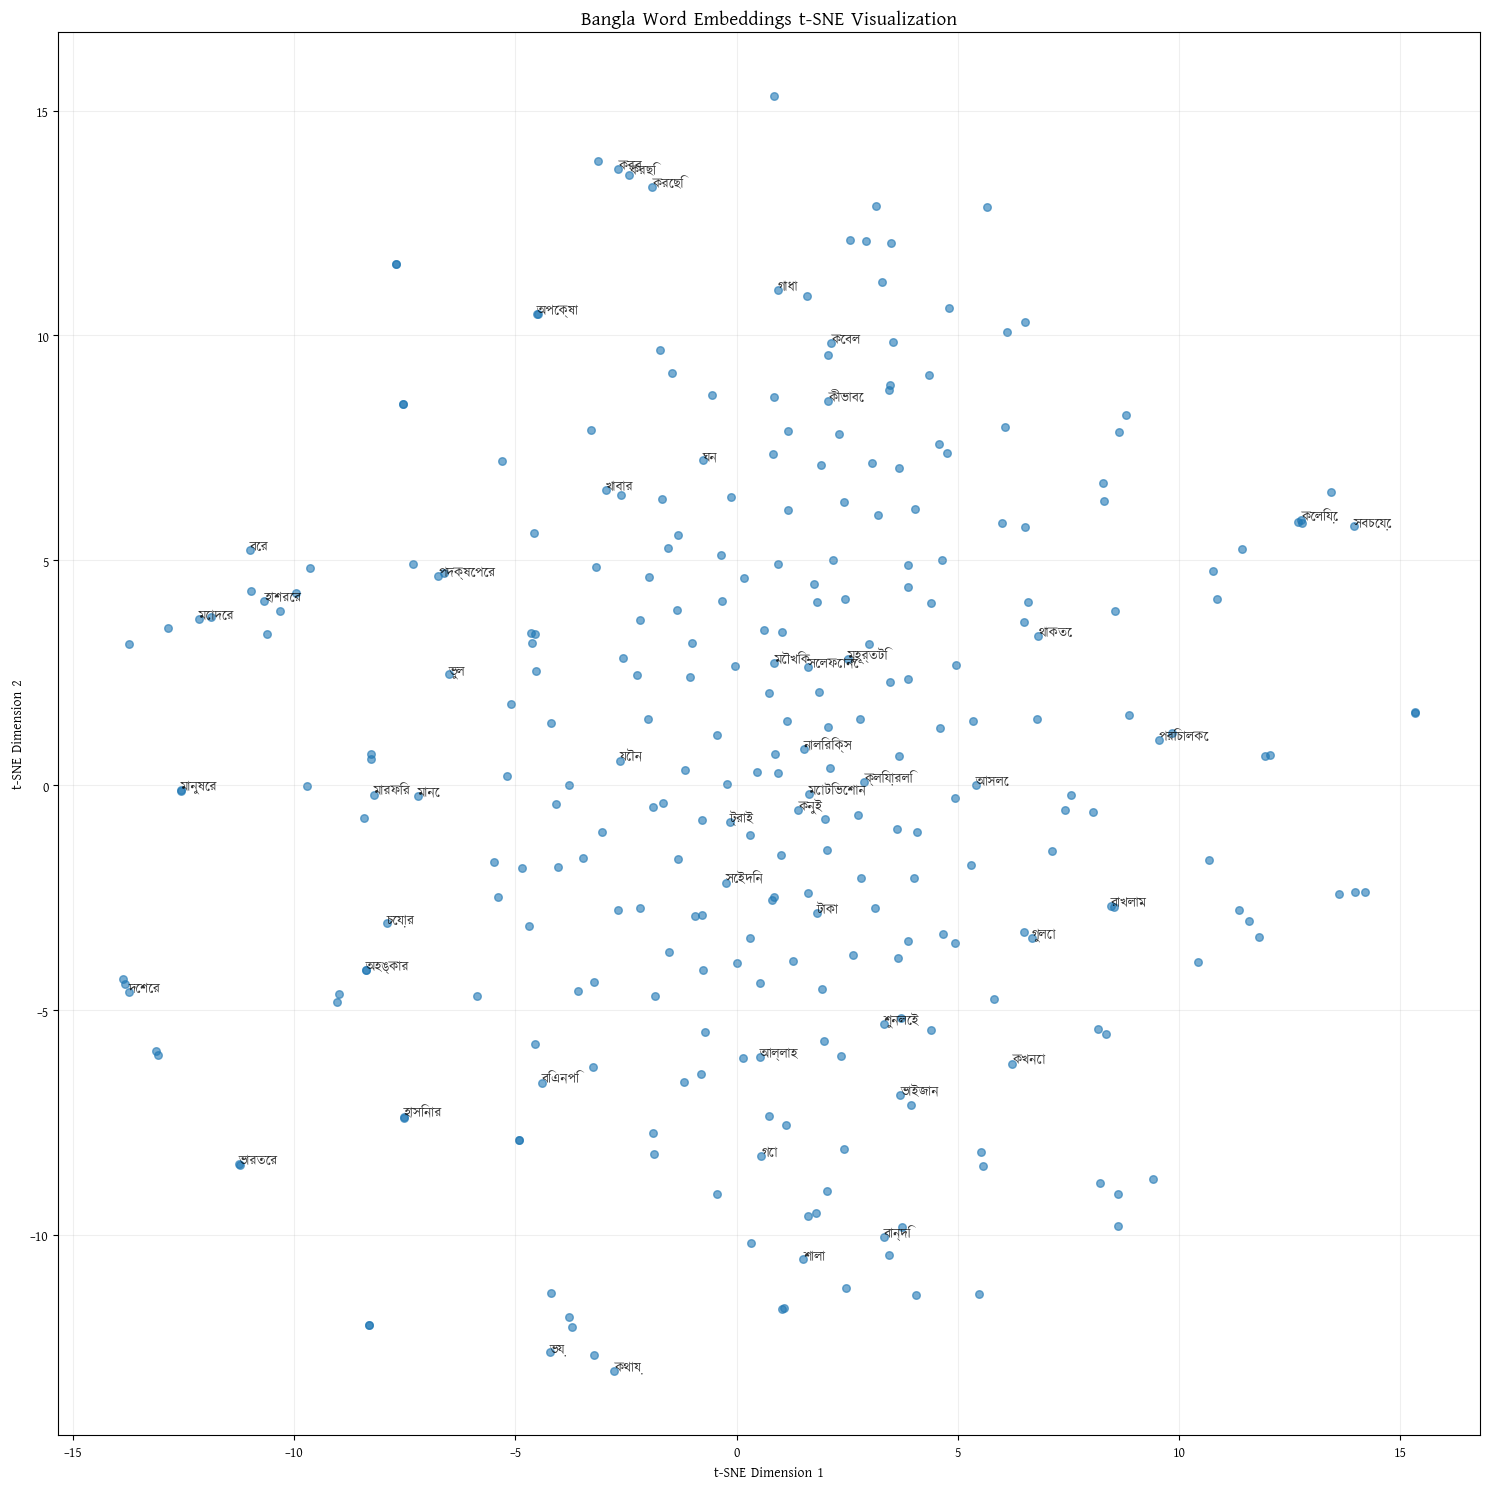

In [35]:
def select_representative_words(model, n_words=300, strategy='mixed'):
    """Select words for visualization"""
    words = list(model.wv.index_to_key)
    word_counts = [(word, model.wv.get_vecattr(word, 'count')) for word in words]
    word_counts.sort(key=lambda x: x[1], reverse=True)
    
    if strategy == 'frequent':
        selected = [w for w, _ in word_counts[:n_words]]
    elif strategy == 'rare':
        selected = [w for w, _ in word_counts[-n_words:]]
    elif strategy == 'mixed':
        n_freq = min(n_words//2, len(word_counts))
        freq_words = [w for w, _ in word_counts[:n_freq]]
        n_rand = min(n_words - n_freq, len(word_counts) - n_freq)
        rand_words = np.random.choice([w for w, _ in word_counts[n_freq:]], 
                                      size=min(n_rand, len(word_counts)-n_freq), 
                                      replace=False) if (len(word_counts) - n_freq) > 0 else []
        selected = freq_words + list(rand_words)
    else:
        selected = np.random.choice(words, min(n_words, len(words)), replace=False)
    
    return selected


def plot_dynamic_tsne_bangla(model, n_words=300, perplexity=30):
    """Dynamic t-SNE plot with Bangla font"""
    selected_words = select_representative_words(model, n_words, 'mixed')
    
    # Get vectors
    vectors = np.array([model.wv[word] for word in selected_words])
    
    # Apply t-SNE
    actual_perp = min(perplexity, len(selected_words) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=actual_perp, n_iter=1000)
    vectors_2d = tsne.fit_transform(vectors)
    
    # Plot
    figsize = (max(14, n_words//20), max(10, n_words//20))
    plt.figure(figsize=figsize)
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.6, s=30)
    
    # Annotate with Bangla font
    annotate_count = min(50, n_words)
    indices = np.random.choice(len(selected_words), annotate_count, replace=False)
    for i in indices:
        word = selected_words[i]
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                    fontproperties=font_prop, fontsize=10, alpha=0.8)
    
    plt.title('Bangla Word Embeddings t-SNE Visualization', fontproperties=font_prop, fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    return selected_words, vectors_2d

# Run t-SNE
selected_words, vectors_2d = plot_dynamic_tsne_bangla(fasttext_model, n_words=300)

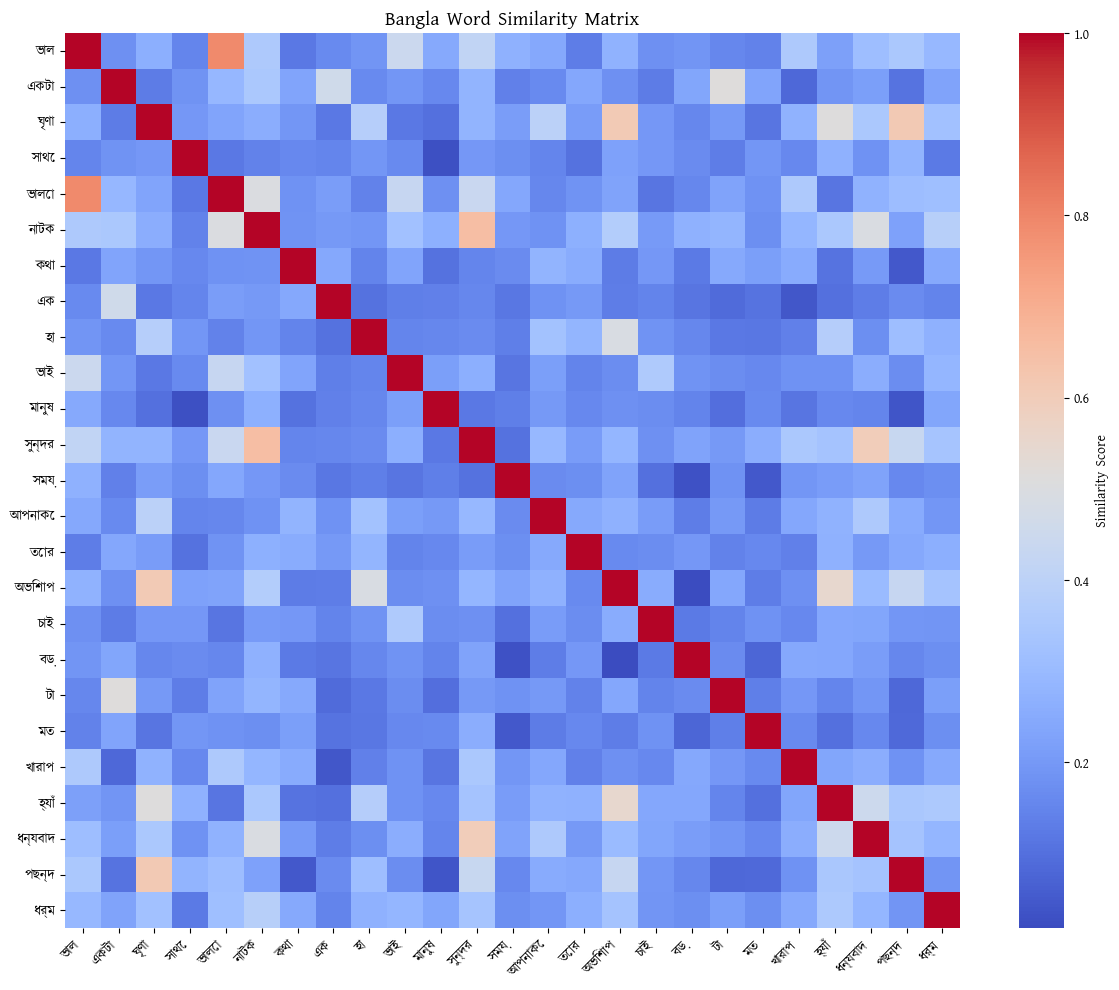

In [36]:
def dynamic_similarity_heatmap_bangla(model, n_words=25):
    """Heatmap with Bangla labels"""
    words = list(model.wv.index_to_key)
    word_counts = [(w, model.wv.get_vecattr(w, 'count')) for w in words]
    word_counts.sort(key=lambda x: x[1], reverse=True)
    selected_words = [w for w, _ in word_counts[:min(n_words, len(word_counts))]]
    
    # Compute similarity matrix
    n = len(selected_words)
    similarity_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            similarity_matrix[i, j] = model.wv.similarity(selected_words[i], selected_words[j])
    
    # Plot
    figsize = (max(10, n*0.5), max(8, n*0.4))
    plt.figure(figsize=figsize)
    ax = sns.heatmap(similarity_matrix,
                     xticklabels=selected_words,
                     yticklabels=selected_words,
                     cmap='coolwarm',
                     annot=n <= 15,
                     fmt='.2f' if n <= 15 else '',
                     square=True,
                     cbar_kws={'label': 'Similarity Score'})
    
    plt.title('Bangla Word Similarity Matrix', fontproperties=font_prop, fontsize=14, fontweight='bold')
    ax.set_xticklabels(selected_words, fontproperties=font_prop, rotation=45, ha='right')
    ax.set_yticklabels(selected_words, fontproperties=font_prop, rotation=0)
    plt.tight_layout()
    plt.show()
    
    return selected_words, similarity_matrix

# Run heatmap
words, sim_matrix = dynamic_similarity_heatmap_bangla(fasttext_model, n_words=25)

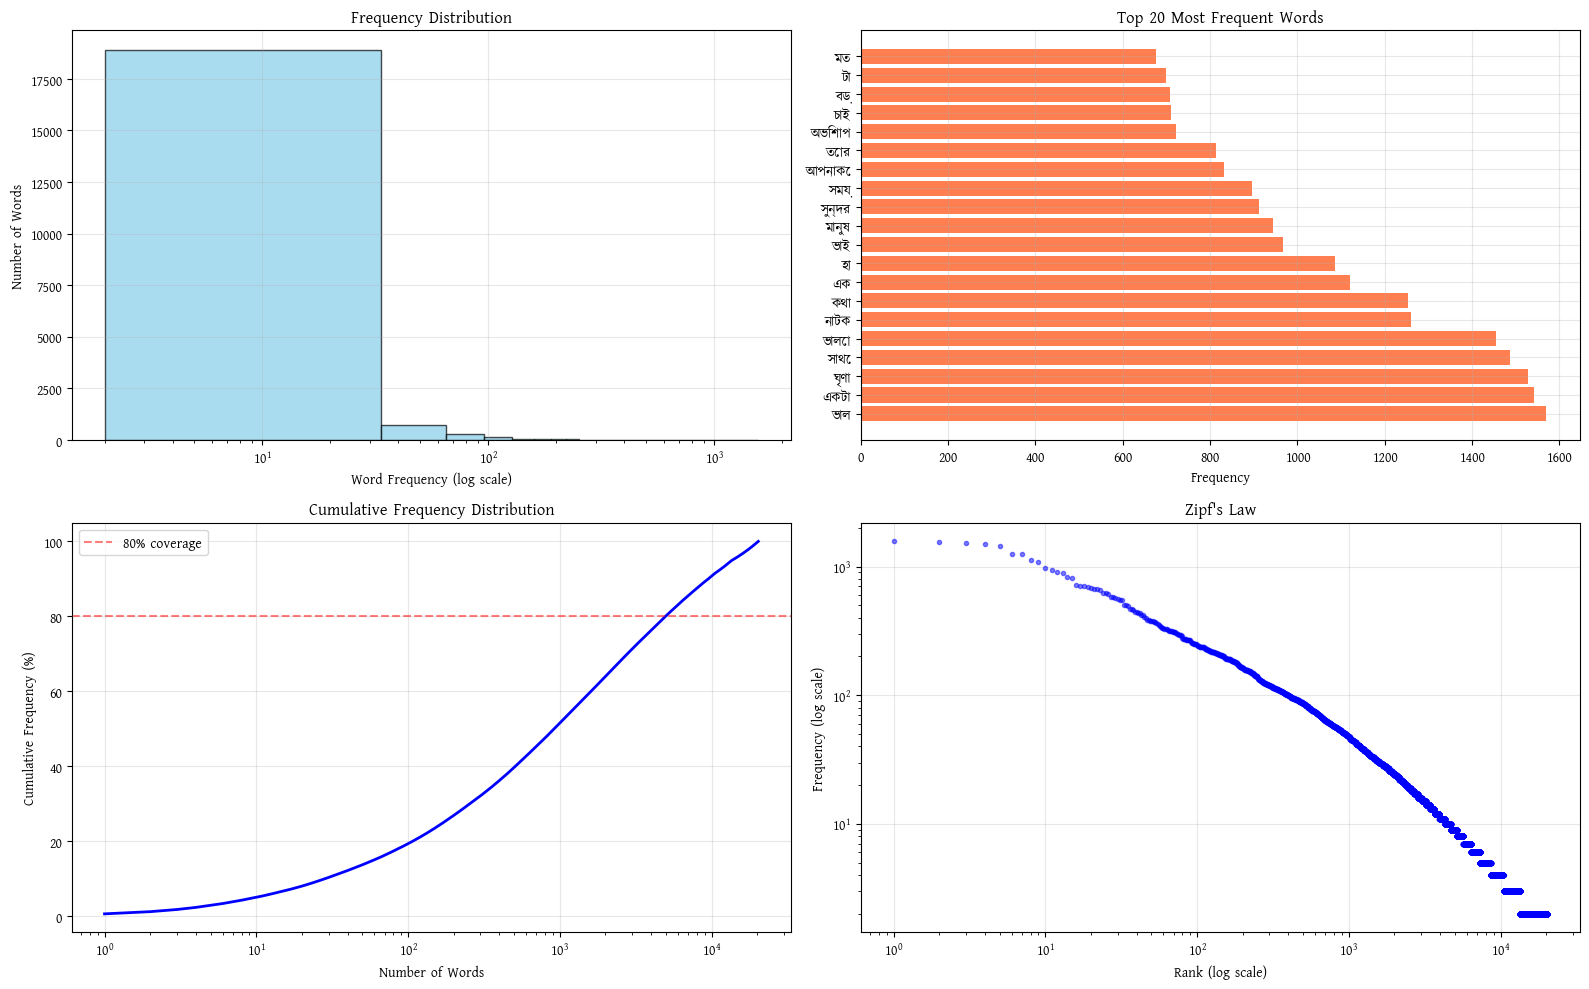

In [37]:
def analyze_frequency_bangla(model):
    """Frequency analysis with Bangla labels"""
    words = list(model.wv.index_to_key)
    frequencies = [model.wv.get_vecattr(w, 'count') for w in words]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Frequency distribution
    axes[0, 0].hist(frequencies, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_xlabel('Word Frequency (log scale)')
    axes[0, 0].set_ylabel('Number of Words')
    axes[0, 0].set_title('Frequency Distribution', fontproperties=font_prop, fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Top 20 words
    top_words = sorted(zip(words, frequencies), key=lambda x: x[1], reverse=True)[:20]
    top_words, top_freqs = zip(*top_words)
    axes[0, 1].barh(range(20), top_freqs, color='coral')
    axes[0, 1].set_yticks(range(20))
    axes[0, 1].set_yticklabels(top_words, fontproperties=font_prop)
    axes[0, 1].set_xlabel('Frequency')
    axes[0, 1].set_title('Top 20 Most Frequent Words', fontproperties=font_prop, fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Cumulative frequency
    sorted_freqs = sorted(frequencies, reverse=True)
    cumulative = np.cumsum(sorted_freqs) / np.sum(sorted_freqs) * 100
    axes[1, 0].plot(range(1, len(cumulative)+1), cumulative, 'b-', linewidth=2)
    axes[1, 0].set_xlabel('Number of Words')
    axes[1, 0].set_ylabel('Cumulative Frequency (%)')
    axes[1, 0].set_title('Cumulative Frequency Distribution', fontproperties=font_prop, fontsize=12)
    axes[1, 0].set_xscale('log')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=80, color='r', linestyle='--', alpha=0.5, label='80% coverage')
    axes[1, 0].legend()
    
    # Zipf's Law
    axes[1, 1].loglog(range(1, len(sorted_freqs)+1), sorted_freqs, 'b.', alpha=0.5)
    axes[1, 1].set_xlabel('Rank (log scale)')
    axes[1, 1].set_ylabel('Frequency (log scale)')
    axes[1, 1].set_title("Zipf's Law", fontproperties=font_prop, fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {'total_words': len(words), 'vocab_size': len(set(words)), 
            'max_freq': max(frequencies), 'min_freq': min(frequencies)}

# Run frequency analysis
stats = analyze_frequency_bangla(fasttext_model)

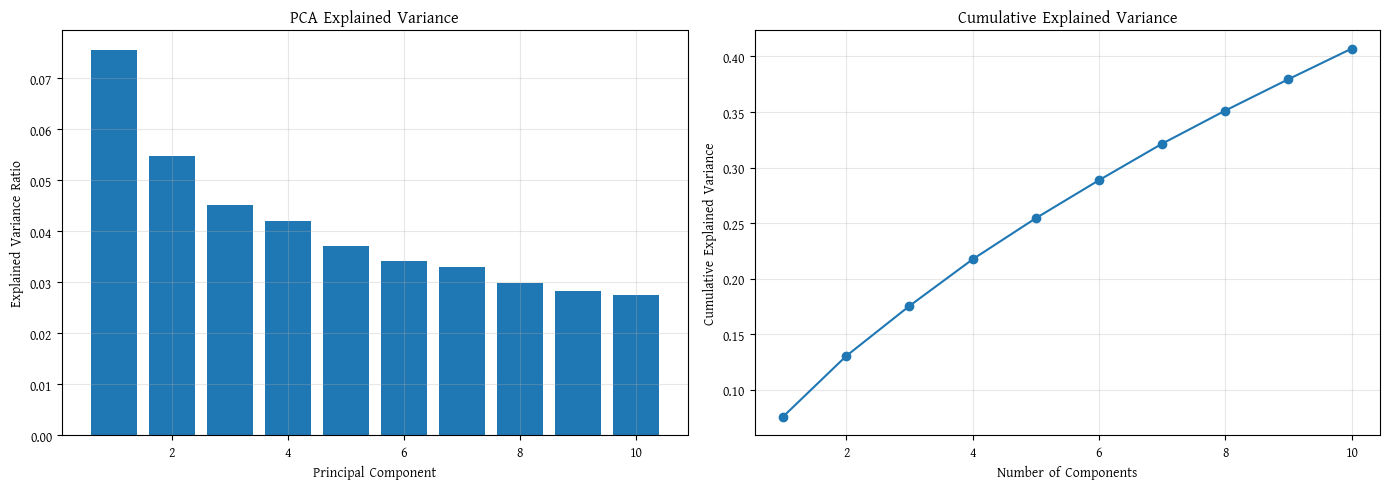

In [38]:
def pca_component_analysis_bangla(model, n_words=1000):
    """PCA analysis with Bangla labels"""
    words = list(model.wv.index_to_key)[:min(n_words, len(model.wv))]
    vectors = np.array([model.wv[word] for word in words])
    
    # Apply PCA
    pca = PCA(n_components=10)
    pca_vectors = pca.fit_transform(vectors)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Explained variance
    axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10])
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('PCA Explained Variance', fontproperties=font_prop, fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Cumulative variance
    axes[1].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_[:10]), marker='o')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title('Cumulative Explained Variance', fontproperties=font_prop, fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return pca

# Run PCA analysis
pca = pca_component_analysis_bangla(fasttext_model)

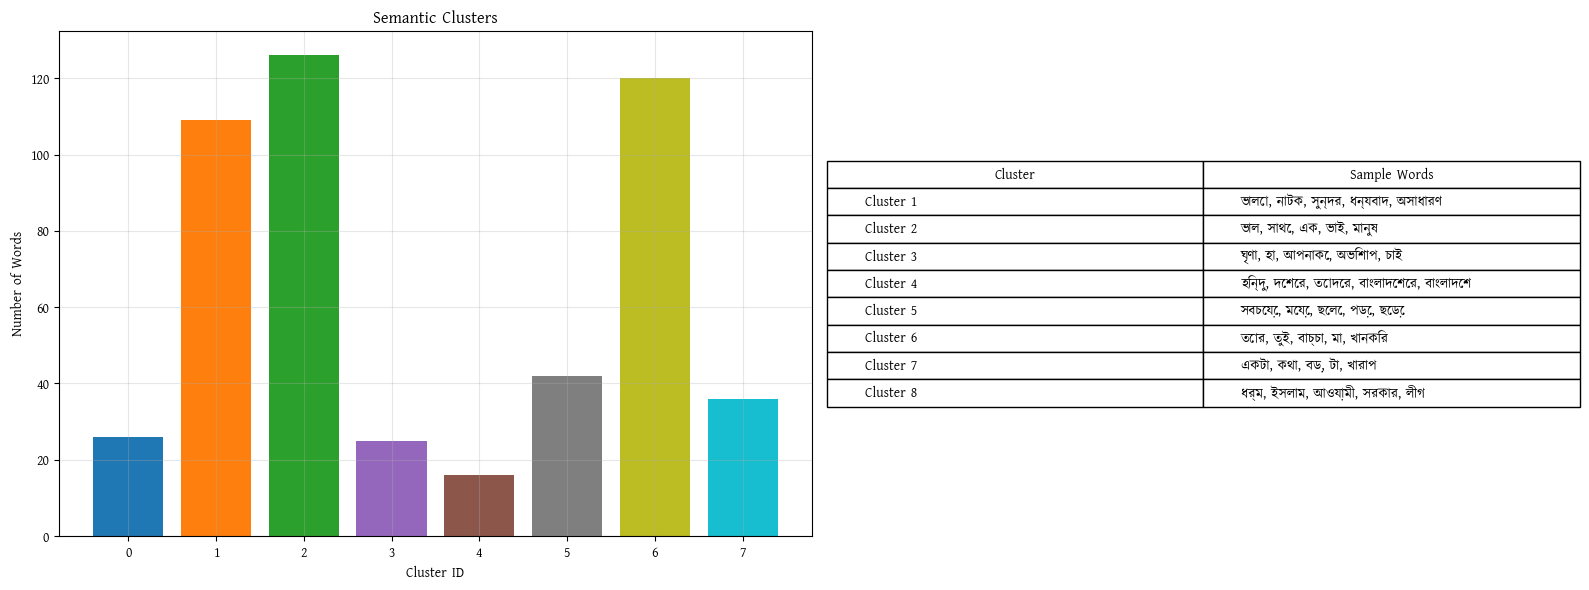

In [39]:
def explore_semantic_clusters_bangla(model, n_clusters=10, n_words=500):
    """Find and visualize semantic clusters"""
    words = list(model.wv.index_to_key)[:min(n_words, len(model.wv))]
    vectors = np.array([model.wv[word] for word in words])
    
    # Cluster
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(vectors)
    
    # Group words by cluster
    cluster_words = defaultdict(list)
    for word, cluster_id in zip(words, clusters):
        cluster_words[cluster_id].append(word)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Cluster sizes
    cluster_sizes = [len(cluster_words[i]) for i in range(n_clusters)]
    axes[0].bar(range(n_clusters), cluster_sizes, color=plt.cm.tab10(np.linspace(0, 1, n_clusters)))
    axes[0].set_xlabel('Cluster ID')
    axes[0].set_ylabel('Number of Words')
    axes[0].set_title('Semantic Clusters', fontproperties=font_prop, fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Sample words per cluster
    axes[1].axis('off')
    table_data = []
    for i in range(n_clusters):
        cluster_word_list = cluster_words[i]
        cluster_word_list.sort(key=lambda w: model.wv.get_vecattr(w, 'count'), reverse=True)
        sample_words = ', '.join(cluster_word_list[:5])
        table_data.append([f'Cluster {i+1}', sample_words])
    
    table = axes[1].table(cellText=table_data,
                         colLabels=['Cluster', 'Sample Words'],
                         loc='center',
                         cellLoc='left')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    plt.tight_layout()
    plt.show()
    
    return cluster_words, kmeans

# Run cluster analysis
cluster_words, kmeans = explore_semantic_clusters_bangla(fasttext_model, n_clusters=8, n_words=500)


Exploring word: ভাল


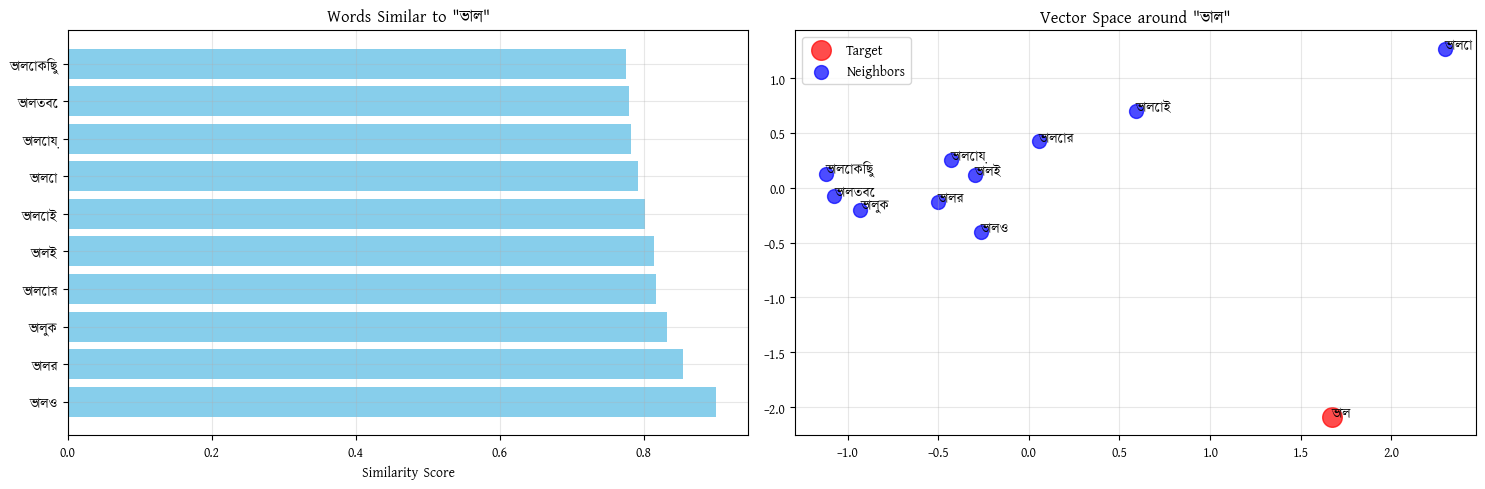

Top 10 neighbors:
 1. ভালও            0.9003
 2. ভালর            0.8549
 3. ভালুক           0.8326
 4. ভালোর           0.8174
 5. ভালই            0.8149
 6. ভালোই           0.8019
 7. ভালো            0.7922
 8. ভালোয়          0.7823
 9. ভালতবে          0.7796
10. ভালোকিছু        0.7755


[('ভালও', 0.9003351926803589),
 ('ভালর', 0.8549264669418335),
 ('ভালুক', 0.8325580358505249),
 ('ভালোর', 0.8174285888671875),
 ('ভালই', 0.8149199485778809),
 ('ভালোই', 0.8019042611122131),
 ('ভালো', 0.7922223806381226),
 ('ভালোয়', 0.7823119163513184),
 ('ভালতবে', 0.7796022891998291),
 ('ভালোকিছু', 0.7754793763160706)]

In [40]:
def find_semantic_neighbors_bangla(model, target_word=None, n_neighbors=10):
    """Find and visualize semantic neighbors"""
    if target_word is None:
        word_counts = [(w, model.wv.get_vecattr(w, 'count')) for w in model.wv.index_to_key]
        word_counts.sort(key=lambda x: x[1], reverse=True)
        target_word = word_counts[0][0]
    
    print(f"\nExploring word: {target_word}")
    print("="*50)
    
    if target_word in model.wv:
        similar = model.wv.most_similar(target_word, topn=n_neighbors)
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Similarity scores
        similar_words, scores = zip(*similar)
        axes[0].barh(similar_words, scores, color='skyblue')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), fontproperties=font_prop)
        axes[0].set_yticklabels(similar_words, fontproperties=font_prop)
        axes[0].set_xlabel('Similarity Score')
        axes[0].set_title(f'Words Similar to "{target_word}"', fontproperties=font_prop, fontsize=12)
        axes[0].grid(True, alpha=0.3)
        
        # 2D projection
        words_to_plot = [target_word] + [w for w, _ in similar]
        vectors = np.array([model.wv[w] for w in words_to_plot])
        words_2d = PCA(n_components=2).fit_transform(vectors)
        
        axes[1].scatter(words_2d[0, 0], words_2d[0, 1], color='red', s=200, alpha=0.7, label='Target')
        axes[1].scatter(words_2d[1:, 0], words_2d[1:, 1], color='blue', s=100, alpha=0.7, label='Neighbors')
        for i, word in enumerate(words_to_plot):
            axes[1].annotate(word, (words_2d[i, 0], words_2d[i, 1]), 
                           fontproperties=font_prop, fontsize=10)
        axes[1].set_title(f'Vector Space around "{target_word}"', fontproperties=font_prop, fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print results
        print(f"Top {n_neighbors} neighbors:")
        for i, (word, score) in enumerate(similar, 1):
            print(f"{i:2d}. {word:15s} {score:.4f}")
        
        return similar
    else:
        print(f"Word '{target_word}' not in vocabulary!")
        return None

# Try with a frequent Bangla word
target = select_representative_words(fasttext_model, n_words=1, strategy='frequent')[0]
find_semantic_neighbors_bangla(fasttext_model, target_word=target)

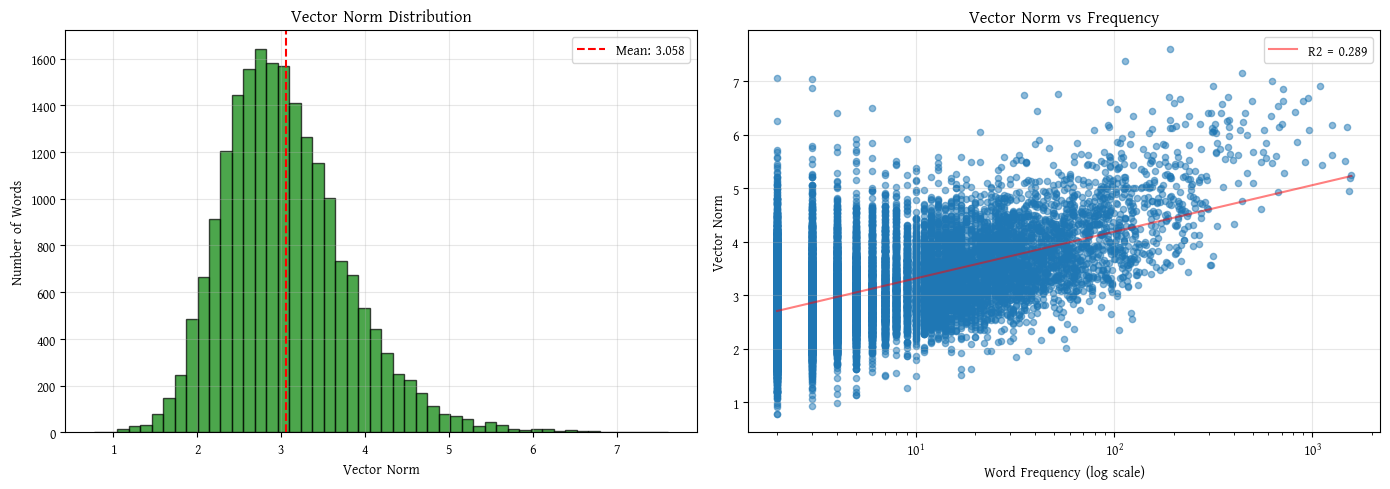

In [41]:
def vector_norm_analysis_bangla(model):
    """Analyze vector norms"""
    words = list(model.wv.index_to_key)
    norms = [np.linalg.norm(model.wv[w]) for w in words]
    frequencies = [model.wv.get_vecattr(w, 'count') for w in words]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Norm distribution
    axes[0].hist(norms, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[0].set_xlabel('Vector Norm')
    axes[0].set_ylabel('Number of Words')
    axes[0].set_title('Vector Norm Distribution', fontproperties=font_prop, fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(np.mean(norms), color='red', linestyle='--', label=f'Mean: {np.mean(norms):.3f}')
    axes[0].legend()
    
    # Norm vs Frequency
    axes[1].scatter(frequencies, norms, alpha=0.5, s=20)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Word Frequency (log scale)')
    axes[1].set_ylabel('Vector Norm')
    axes[1].set_title('Vector Norm vs Frequency', fontproperties=font_prop, fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    # Add trend line
    from scipy import stats
    log_freqs = np.log10([max(f, 1) for f in frequencies])
    slope, intercept, r_value, _, _ = stats.linregress(log_freqs, norms)
    x_range = np.array([min(frequencies), max(frequencies)])
    axes[1].plot(x_range, slope * np.log10(x_range) + intercept, 'r-', 
                alpha=0.5, label=f'R2 = {r_value**2:.3f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {'mean_norm': np.mean(norms), 'std_norm': np.std(norms), 
            'max_norm': np.max(norms), 'min_norm': np.min(norms)}

# Run norm analysis
norm_stats = vector_norm_analysis_bangla(fasttext_model)

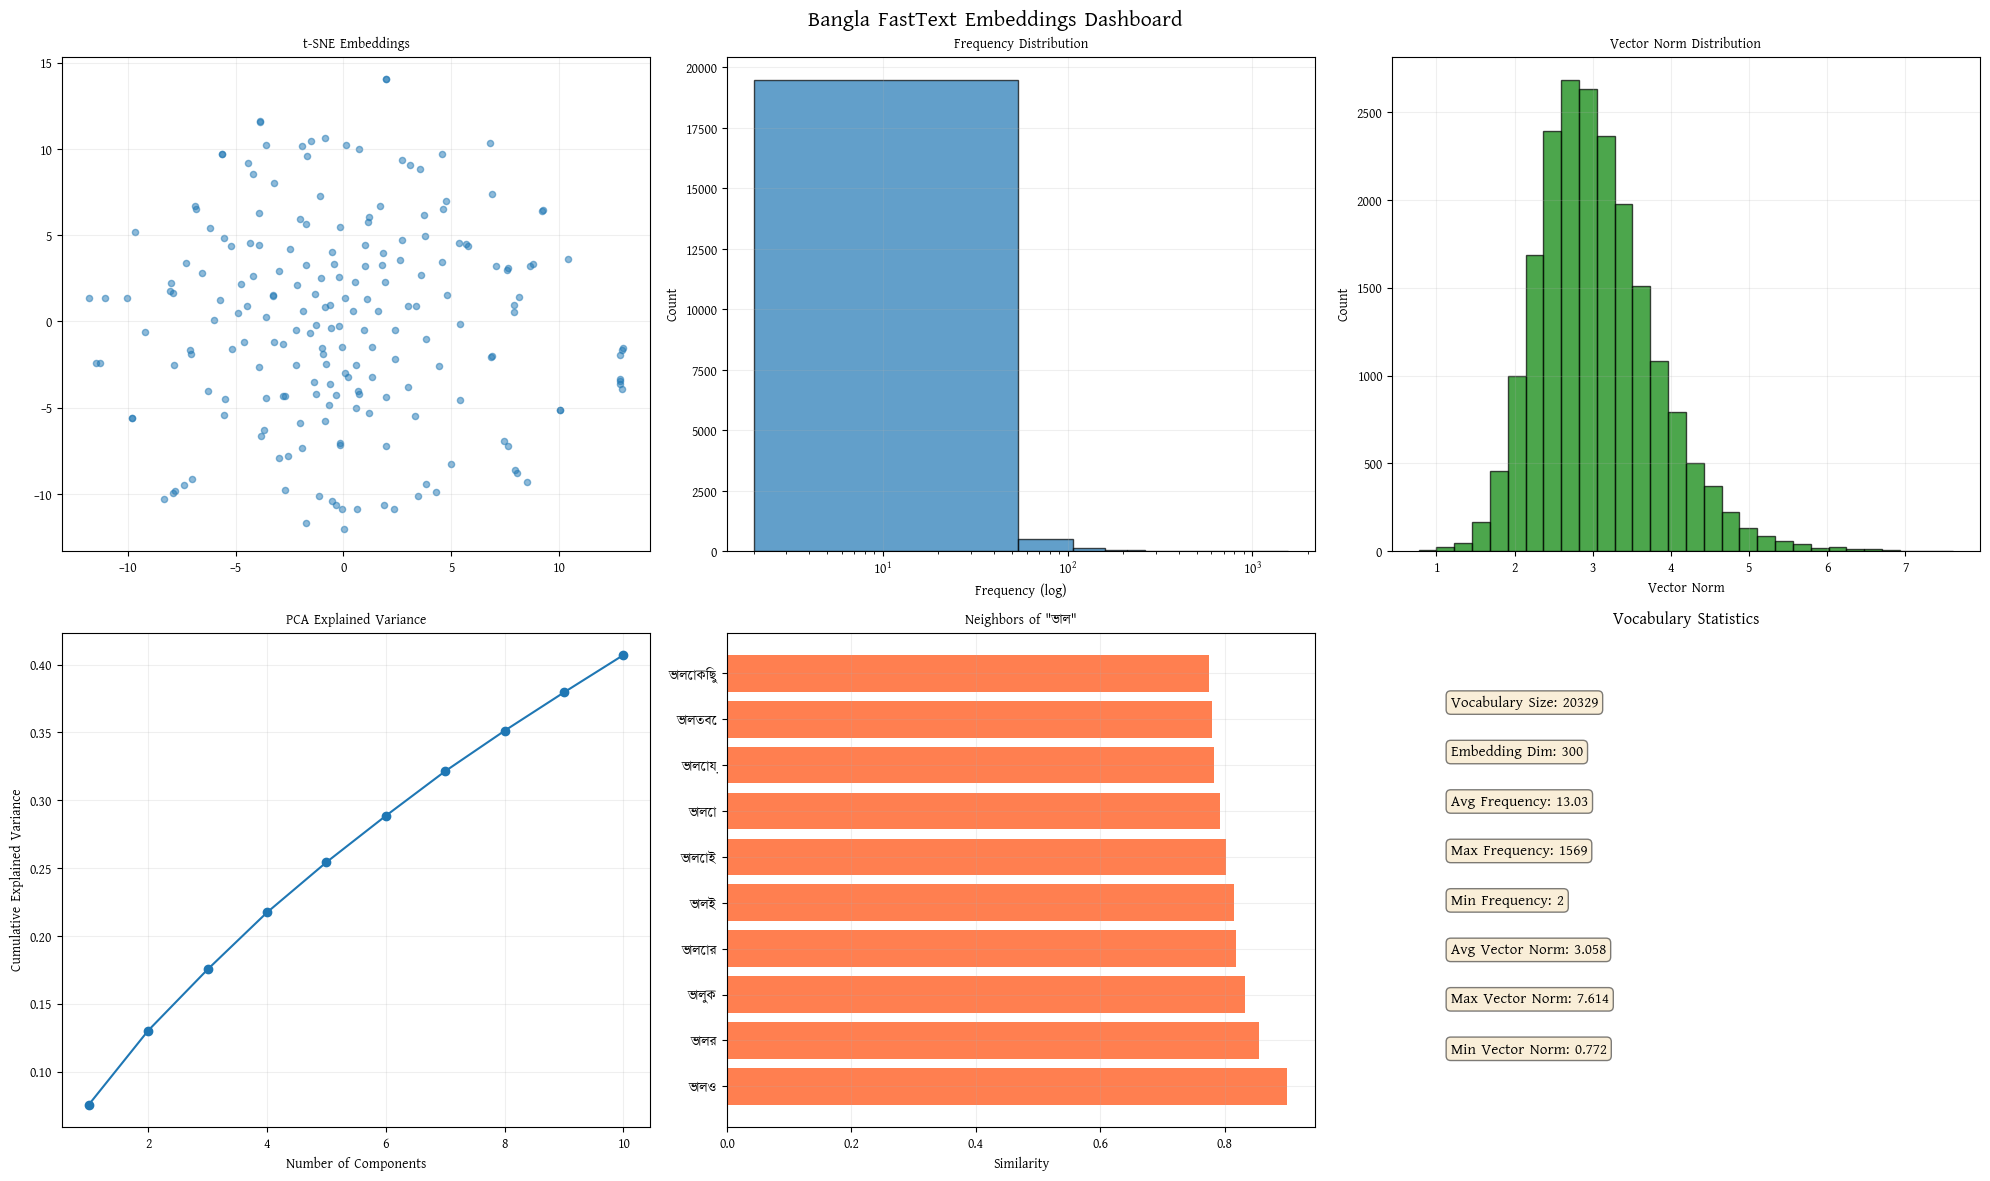

In [42]:
def create_embedding_dashboard_bangla(model):
    """Create comprehensive dashboard with multiple visualizations"""
    fig = plt.figure(figsize=(20, 12))
    
    # 1. t-SNE
    ax1 = plt.subplot(2, 3, 1)
    selected = select_representative_words(model, n_words=200, strategy='frequent')
    vectors = np.array([model.wv[word] for word in selected])
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(selected)-1))
    vectors_2d = tsne.fit_transform(vectors)
    ax1.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5, s=20)
    ax1.set_title('t-SNE Embeddings', fontproperties=font_prop, fontsize=10)
    ax1.grid(True, alpha=0.2)
    
    # 2. Frequency Distribution
    ax2 = plt.subplot(2, 3, 2)
    freqs = [model.wv.get_vecattr(w, 'count') for w in model.wv.index_to_key]
    ax2.hist(freqs, bins=30, edgecolor='black', alpha=0.7)
    ax2.set_xscale('log')
    ax2.set_xlabel('Frequency (log)')
    ax2.set_ylabel('Count')
    ax2.set_title('Frequency Distribution', fontproperties=font_prop, fontsize=10)
    ax2.grid(True, alpha=0.2)
    
    # 3. Vector Norms
    ax3 = plt.subplot(2, 3, 3)
    norms = [np.linalg.norm(model.wv[w]) for w in model.wv.index_to_key]
    ax3.hist(norms, bins=30, edgecolor='black', alpha=0.7, color='green')
    ax3.set_xlabel('Vector Norm')
    ax3.set_ylabel('Count')
    ax3.set_title('Vector Norm Distribution', fontproperties=font_prop, fontsize=10)
    ax3.grid(True, alpha=0.2)
    
    # 4. PCA Explained Variance
    ax4 = plt.subplot(2, 3, 4)
    all_vectors = np.array([model.wv[word] for word in model.wv.index_to_key[:1000]])
    pca = PCA(n_components=10)
    pca.fit(all_vectors)
    ax4.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), marker='o')
    ax4.set_xlabel('Number of Components')
    ax4.set_ylabel('Cumulative Explained Variance')
    ax4.set_title('PCA Explained Variance', fontproperties=font_prop, fontsize=10)
    ax4.grid(True, alpha=0.2)
    
    # 5. Most Similar Example
    ax5 = plt.subplot(2, 3, 5)
    if len(model.wv.index_to_key) > 0:
        word = model.wv.index_to_key[0]
        similar = model.wv.most_similar(word, topn=10)
        similar_words, scores = zip(*similar)
        ax5.barh(similar_words, scores, color='coral')
        ax5.set_yticklabels(similar_words, fontproperties=font_prop)
        ax5.set_xlabel('Similarity')
        ax5.set_title(f'Neighbors of "{word}"', fontproperties=font_prop, fontsize=10)
        ax5.grid(True, alpha=0.2)
    
    # 6. Vocabulary Stats
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    stats_text = [
        f"Vocabulary Size: {len(model.wv)}",
        f"Embedding Dim: {model.vector_size}",
        f"Avg Frequency: {np.mean(freqs):.2f}",
        f"Max Frequency: {max(freqs)}",
        f"Min Frequency: {min(freqs)}",
        f"Avg Vector Norm: {np.mean(norms):.3f}",
        f"Max Vector Norm: {np.max(norms):.3f}",
        f"Min Vector Norm: {np.min(norms):.3f}",
    ]
    for i, text in enumerate(stats_text):
        ax6.text(0.1, 0.85 - i*0.1, text, fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax6.set_title('Vocabulary Statistics', fontproperties=font_prop, fontsize=12)
    
    plt.suptitle('Bangla FastText Embeddings Dashboard', fontproperties=font_prop, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Create dashboard
create_embedding_dashboard_bangla(fasttext_model)

In [43]:
# ============================================================
# Cell Construct FastText Embedding Matrix
# ============================================================

# Number of tokens in the Keras vocabulary.
vocab_size = len(vocabulary)

# Initialize embedding matrix.
embedding_matrix = np.zeros((vocab_size, FASTTEXT_VECTOR_SIZE),dtype=np.float32)

# Track how many vocabulary words have FastText vectors.
found_vectors = 0

# Build the embedding matrix.
for index, word in enumerate(vocabulary):

    # Skip padding and unknown tokens.
    if index == 0 or word == "[UNK]":
        continue

    # FastText can generate vectors for known and many
    # out-of-vocabulary words through subword representations.
    try:
        embedding_matrix[index] = (fasttext_model.wv.get_vector(word))
        found_vectors += 1

    except KeyError:
        pass


print("Embedding matrix shape:", embedding_matrix.shape)
print("Vectors initialized:", found_vectors)
print("Coverage: "f"{found_vectors / max(1, vocab_size - 2) * 100:.2f}%")

Embedding matrix shape: (30000, 300)
Vectors initialized: 29998
Coverage: 100.00%


In [44]:
# ============================================================
# Cell Convert Text to Integer Sequences
# ============================================================

X_train_seq = vectorizer(tf.constant(X_train)).numpy()

X_val_seq = vectorizer(tf.constant(X_val)).numpy()

X_test_seq = vectorizer(tf.constant(X_test)).numpy()

print("Training tensor shape:", X_train_seq.shape)
print("Validation tensor shape:", X_val_seq.shape)
print("Test tensor shape:", X_test_seq.shape)

Training tensor shape: (29252, 150)
Validation tensor shape: (3657, 150)
Test tensor shape: (3657, 150)


In [45]:
# ============================================================
# Cell Compute Class Weights
# ============================================================

# Calculate balanced class weights using training labels only.
classes = np.unique(y_train)

weights = compute_class_weight(class_weight="balanced", classes=classes,y=y_train)

class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}

print("Class weights:")
print(class_weights)

Class weights:
{0: 0.8114735907678651, 1: 1.3026362664766655}


In [46]:
# ============================================================
# Cell Create TensorFlow Data Pipelines
# ============================================================

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train))

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val))

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test))

# Shuffle only the training dataset.
train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=len(X_train_seq),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [47]:
# ============================================================
# Cell FastText + CNN + BiLSTM Model
# ============================================================



def build_fasttext_cnn_bilstm_model(
    vocab_size,
    embedding_dim,
    embedding_matrix,
    max_sequence_length,
    trainable=True
):
    """
    Build a FastText-initialized CNN + BiLSTM classifier.
    """

    # --------------------------------------------------------
    # Input layer
    # --------------------------------------------------------

    inputs = Input(
        shape=(max_sequence_length,),
        dtype=tf.int32,
        name="input_tokens"
    )

    # --------------------------------------------------------
    # FastText embedding layer
    # --------------------------------------------------------

    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(
            embedding_matrix
        ),
        trainable=trainable,
        mask_zero=True,
        name="fasttext_embedding"
    )(inputs)

    # Apply spatial dropout to reduce overfitting.
    x = SpatialDropout1D(
        rate=0.20,
        name="embedding_dropout"
    )(embedding)

    # --------------------------------------------------------
    # CNN feature extraction
    # --------------------------------------------------------

    cnn_3 = Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="cnn_kernel_3"
    )(x)

    cnn_3 = BatchNormalization(
        name="cnn_bn_3"
    )(cnn_3)

    cnn_5 = Conv1D(
        filters=128,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="cnn_kernel_5"
    )(x)

    cnn_5 = BatchNormalization(
        name="cnn_bn_5"
    )(cnn_5)

    # Combine different local receptive fields.
    cnn_features = Concatenate(
        name="cnn_feature_fusion"
    )([cnn_3, cnn_5])

    cnn_features = Dropout(
        0.20,
        name="cnn_dropout"
    )(cnn_features)

    # --------------------------------------------------------
    # BiLSTM contextual representation
    # --------------------------------------------------------

    lstm_features = Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            dropout=0.20,
            recurrent_dropout=0.0
        ),
        name="bilstm"
    )(cnn_features)

    # --------------------------------------------------------
    # Global pooling
    # --------------------------------------------------------

    max_features = GlobalMaxPooling1D(
        name="global_max_pooling"
    )(lstm_features)

    avg_features = GlobalAveragePooling1D(
        name="global_average_pooling"
    )(lstm_features)

    # Fuse both representations.
    features = Concatenate(
        name="pooling_fusion"
    )([
        max_features,
        avg_features
    ])

    # --------------------------------------------------------
    # Classification head
    # --------------------------------------------------------

    features = Dense(
        128,
        activation="relu",
        name="dense_features"
    )(features)

    features = Dropout(
        0.40,
        name="classifier_dropout"
    )(features)

    outputs = Dense(
        1,
        activation="sigmoid",
        name="binary_output"
    )(features)

    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="FastText_CNN_BiLSTM"
    )

    return model


model = build_fasttext_cnn_bilstm_model(
    vocab_size=vocab_size,
    embedding_dim=FASTTEXT_VECTOR_SIZE,
    embedding_matrix=embedding_matrix,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    trainable=EMBEDDING_TRAINABLE
)

model.summary()

Model: "FastText_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fasttext_embedding  │ (None, 150, 300)  │  9,000,000 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 150, 300)  │          0 │ fasttext_embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_kernel_3        │ (None, 150, 128)  │    115,328 │ embedding_dropou… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_kernel_5        │ (None, 150, 128)  │    192,128 │ embedding_dropou… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_3            │ (None, 150, 128)  │        512 │ cnn_kernel_3[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_5            │ (None, 150, 128)  │        512 │ cnn_kernel_5[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_feature_fusion  │ (None, 150, 256)  │          0 │ cnn_bn_3[0][0],   │
│ (Concatenate)       │                   │            │ cnn_bn_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout         │ (None, 150, 256)  │          0 │ cnn_feature_fusi… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 150, 256)  │    394,240 │ cnn_dropout[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling  │ (None, 256)       │          0 │ bilstm[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ bilstm[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_fusion      │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 128)       │     65,664 │ pooling_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dropout  │ (None, 128)       │          0 │ dense_features[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary_output       │ (None, 1)         │        129 │ classifier_dropo… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,768,513 (37.26 MB)

 Trainable params: 9,768,001 (37.26 MB)

 Non-trainable params: 512 (2.00 KB)

In [48]:
# ============================================================
# Cell Compile Model
# ============================================================

# Define Adam optimizer with a conservative learning rate.
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

# Compile the binary classification model.
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [49]:
# ============================================================
# Cell Training Callbacks
# ============================================================

# Save the model with the best validation F1-related proxy.
# Since Keras does not directly provide validation F1 as a
# built-in checkpoint monitor, validation loss is used here.
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

# Stop training when validation performance stops improving.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

print("Callbacks configured.")

Callbacks configured.


In [50]:
# ============================================================
# Cell Train FastText + CNN + BiLSTM
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7966 - loss: 0.4590 - pr_auc: 0.8166 - precision: 0.7353 - recall: 0.7220 - roc_auc: 0.8540
Epoch 1: val_loss improved from None to 0.45719, saving model to /kaggle/working/best_fasttext_cnn_bilstm.keras

Epoch 1: finished saving model to /kaggle/working/best_fasttext_cnn_bilstm.keras
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.8237 - loss: 0.4215 - pr_auc: 0.8538 - precision: 0.7825 - recall: 0.7489 - roc_auc: 0.8813 - val_accuracy: 0.8031 - val_loss: 0.4572 - val_pr_auc: 0.8744 - val_precision: 0.7111 - val_recall: 0.8205 - val_roc_auc: 0.8968 - learning_rate: 0.0010
Epoch 2/100
457/458 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8599 - loss: 0.3439 - pr_auc: 0.9028 - precision: 0.8312 - recall: 0.7976 - roc_auc: 0.9239
Epoch 2: val_loss improved from 0.45719 to 0.37803, saving model to /kaggle/working/best_fasttext_cnn_bilstm.keras

Epoch 2: finished saving model to /kaggle/working/best_fasttext_cnn

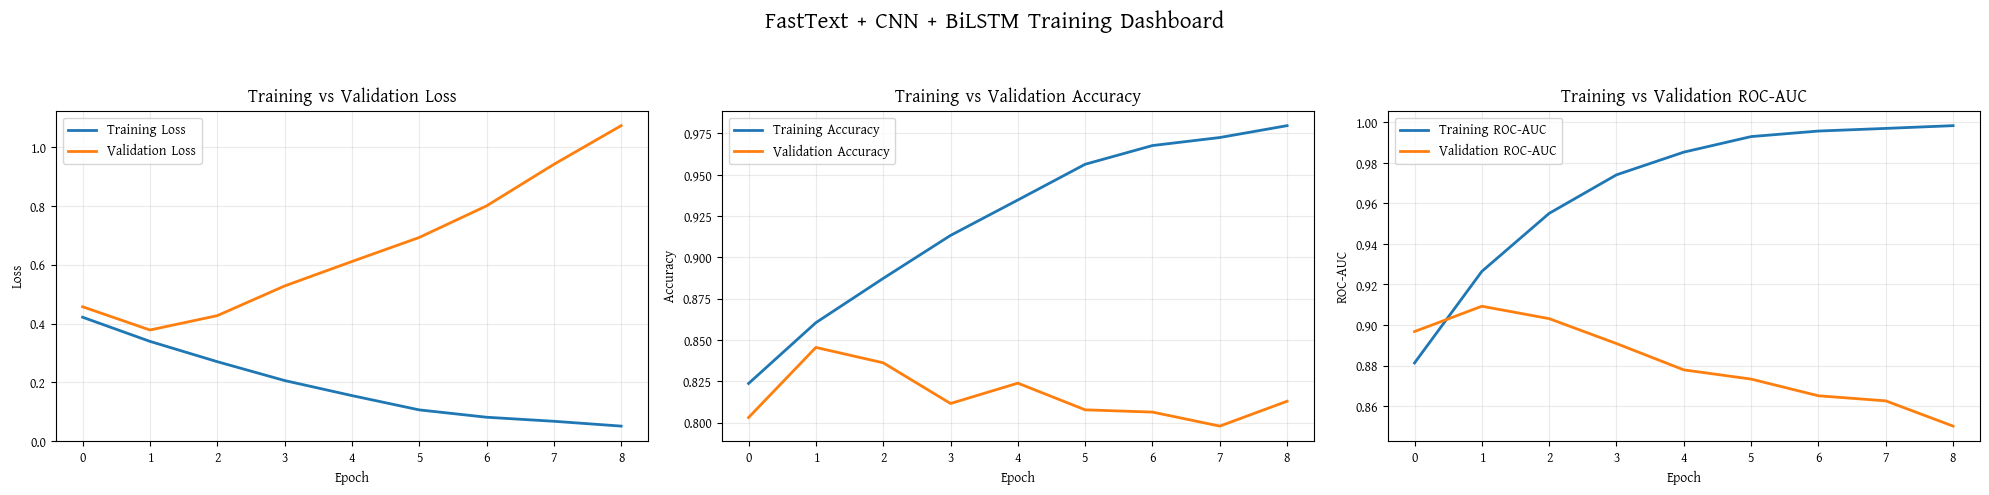

In [51]:
# ============================================================
# Cell Unified Training Dashboard
# ============================================================

# Create a single dashboard containing the three most important
# training curves: Loss, Accuracy, and ROC-AUC.

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

# ------------------------------------------------------------
# 1. Loss
# ------------------------------------------------------------

axes[0].plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

axes[0].plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

axes[0].set_title(
    "Training vs Validation Loss",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

# ------------------------------------------------------------
# 2. Accuracy
# ------------------------------------------------------------

axes[1].plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

axes[1].plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

axes[1].set_title(
    "Training vs Validation Accuracy",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

# ------------------------------------------------------------
# 3. ROC-AUC
# ------------------------------------------------------------

axes[2].plot(
    history.history["roc_auc"],
    label="Training ROC-AUC",
    linewidth=2
)

axes[2].plot(
    history.history["val_roc_auc"],
    label="Validation ROC-AUC",
    linewidth=2
)

axes[2].set_title(
    "Training vs Validation ROC-AUC",
    fontsize=13,
    fontweight="bold"
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("ROC-AUC")
axes[2].legend()
axes[2].grid(alpha=0.25)

# ------------------------------------------------------------
# Dashboard formatting
# ------------------------------------------------------------

fig.suptitle(
    "FastText + CNN + BiLSTM Training Dashboard",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

In [52]:
# ============================================================
# Cell Load Best Saved Model

# Load the best checkpoint selected using validation loss.
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Best model loaded successfully.")

Best model loaded successfully.


In [53]:
# ============================================================
# Cell Evaluate Test Set
# ============================================================

test_results = best_model.evaluate(test_dataset,verbose=1,return_dict=True)

print("\nTest Set Results")
print("=" * 60)

for metric_name, metric_value in test_results.items():
    print(f"{metric_name:<15}: " f"{metric_value:.4f}")

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8592 - loss: 0.3281 - pr_auc: 0.9110 - precision: 0.8295 - recall: 0.7970 - roc_auc: 0.9267

Test Set Results
accuracy       : 0.8592
loss           : 0.3281
pr_auc         : 0.9110
precision      : 0.8295
recall         : 0.7970
roc_auc        : 0.9267


In [54]:
# ============================================================
# Cell Generate Test Predictions
# ============================================================

# Generate probability predictions using the prepared
# TensorFlow test dataset.
y_prob = best_model.predict(test_dataset,verbose=1).ravel()

# Convert predicted probabilities into binary predictions.
# 0.50 is used as the default decision threshold.
y_pred = (y_prob >= 0.50).astype(int)

# Display prediction information.
print("Prediction shape:", y_pred.shape)

print("Probability range:", f"{y_prob.min():.4f}", "-", f"{y_prob.max():.4f}")

print("Predicted class distribution:")

print(pd.Series(y_pred).value_counts().sort_index())

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Prediction shape: (3657,)
Probability range: 0.0006 - 0.9982
Predicted class distribution:
0    2308
1    1349
Name: count, dtype: int64


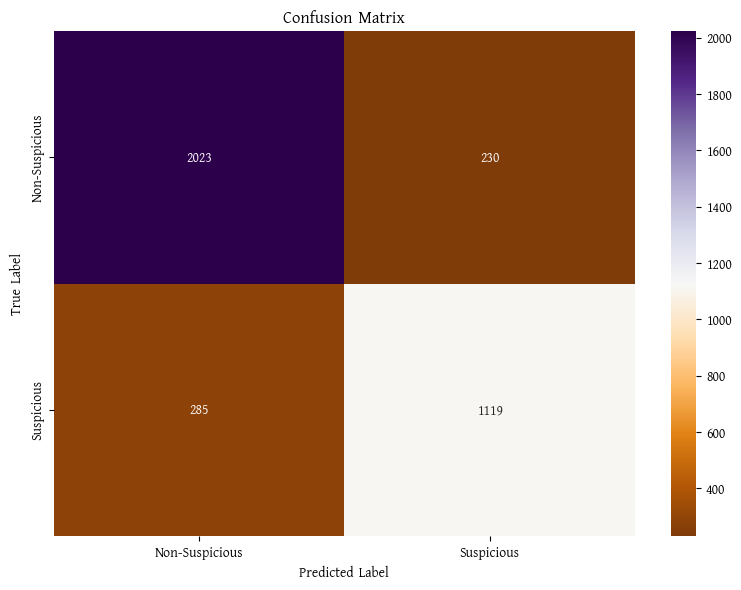

In [55]:
# ============================================================
# Cell Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm,annot=True,fmt="d",
    cmap="PuOr",
    xticklabels=[
        "Non-Suspicious",
        "Suspicious"
    ],
    yticklabels=[
        "Non-Suspicious",
        "Suspicious"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

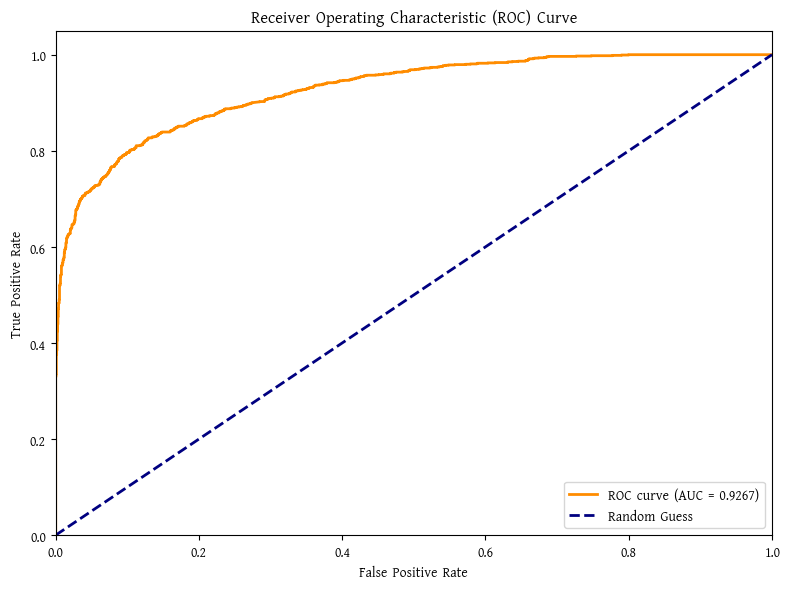

In [56]:
# ============================================================
# Cell ROC Curve
# ============================================================


# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color="darkorange", lw=2, 
         label=f"ROC curve (AUC = {roc_auc:.4f})")

# Plot the diagonal line representing a random guess
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", 
         label="Random Guess")

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

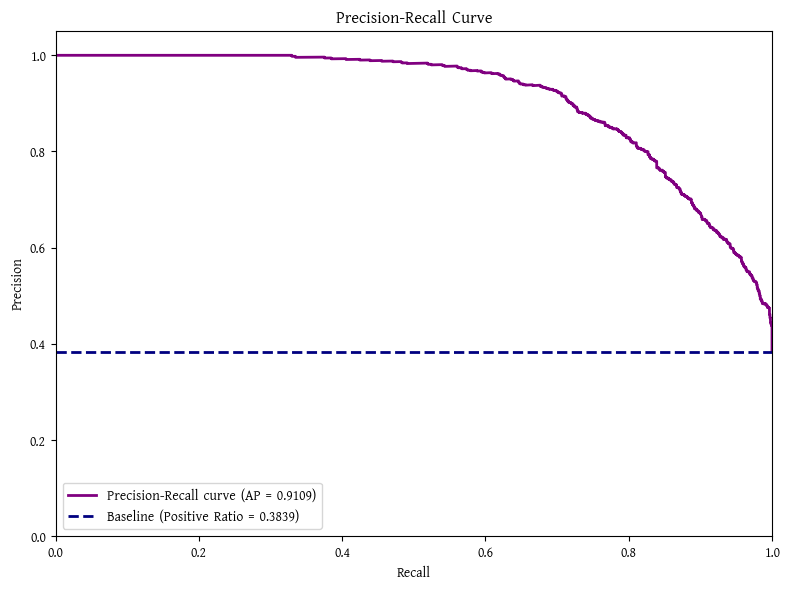

In [57]:
# ============================================================
# Cell Precision-Recall Curve
# ============================================================

# Compute Precision, Recall, and Thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Compute Average Precision (AP) score
ap_score = average_precision_score(y_test, y_prob)

# Plot the Precision-Recall curve
plt.figure(figsize=(8,6))

plt.plot(recall, precision, color="purple", lw=2, 
         label=f"Precision-Recall curve (AP = {ap_score:.4f})")

# Calculate the ratio of positive cases to plot the baseline
# (Baseline is a horizontal line at the ratio of positive cases in the dataset)
positive_ratio = sum(y_test) / len(y_test)
plt.axhline(y=positive_ratio, color="navy", lw=2, linestyle="--", 
            label=f"Baseline (Positive Ratio = {positive_ratio:.4f})")

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

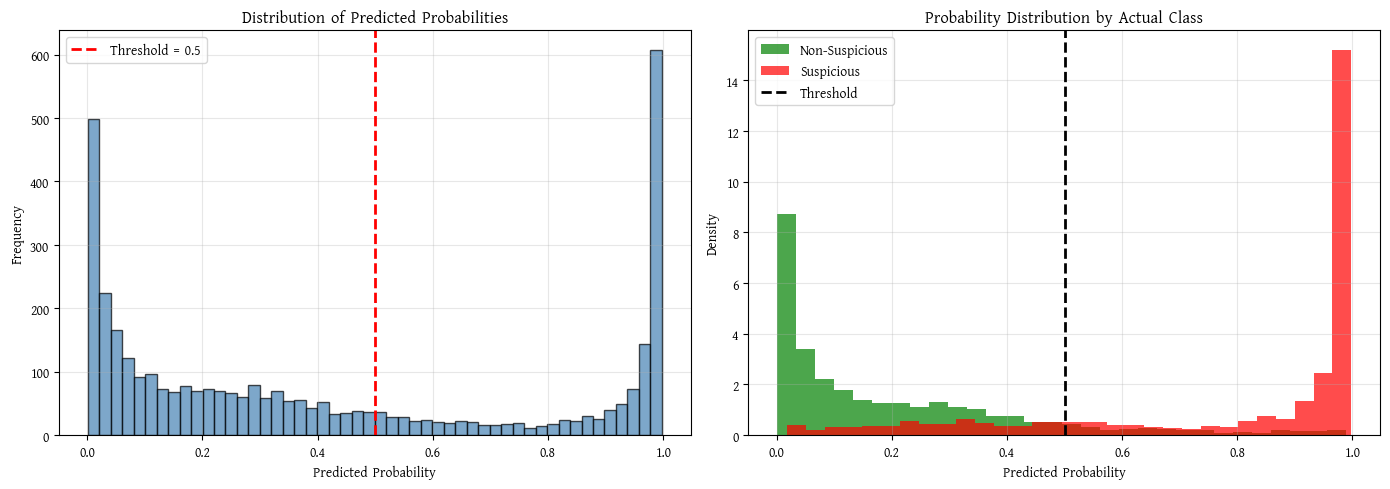

In [58]:
# Prediction Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predicted probabilities
axes[0].hist(y_prob, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution by actual class
axes[1].hist(y_prob[y_test == 0], bins=30, alpha=0.7, color='green', label='Non-Suspicious', density=True)
axes[1].hist(y_prob[y_test == 1], bins=30, alpha=0.7, color='red', label='Suspicious', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distribution by Actual Class')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

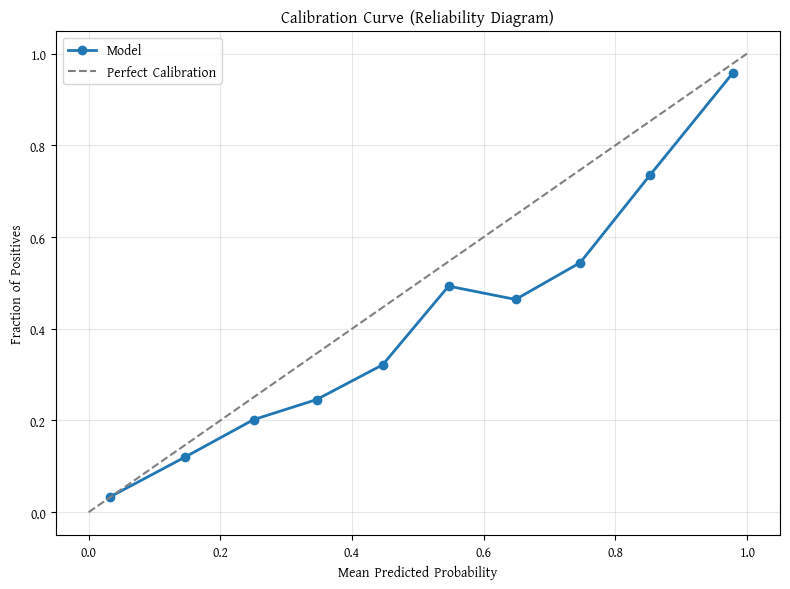

In [59]:
# Calibration Curve
fig, ax = plt.subplots(figsize=(8, 6))

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Reliability Diagram)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

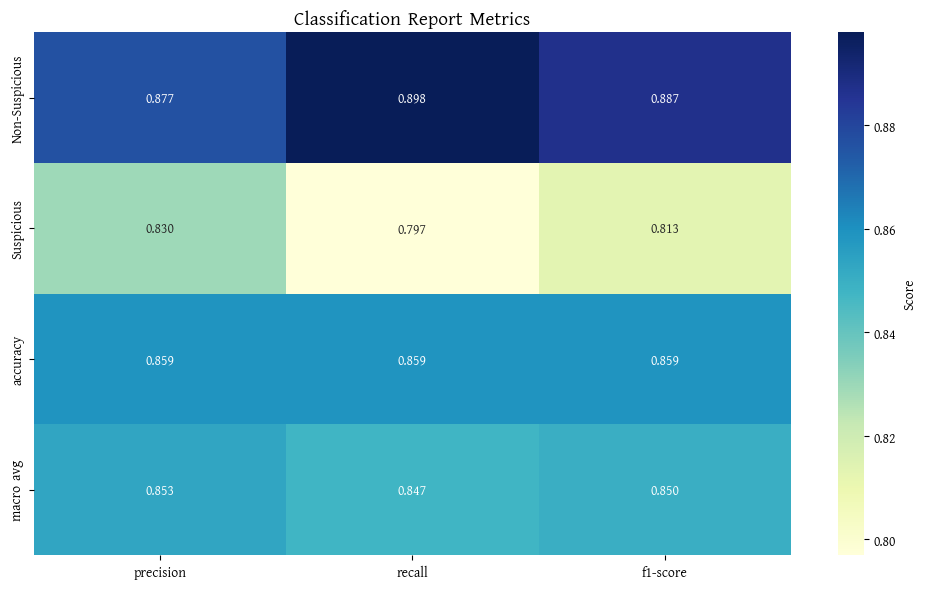

In [60]:
# Classification Report as Heatmap
report = classification_report(y_test, y_pred, 
                              target_names=['Non-Suspicious', 'Suspicious'], 
                              output_dict=True)
report_df = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Score'}, ax=ax)
ax.set_title('Classification Report Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Total misclassified: 515
Total correct: 3142


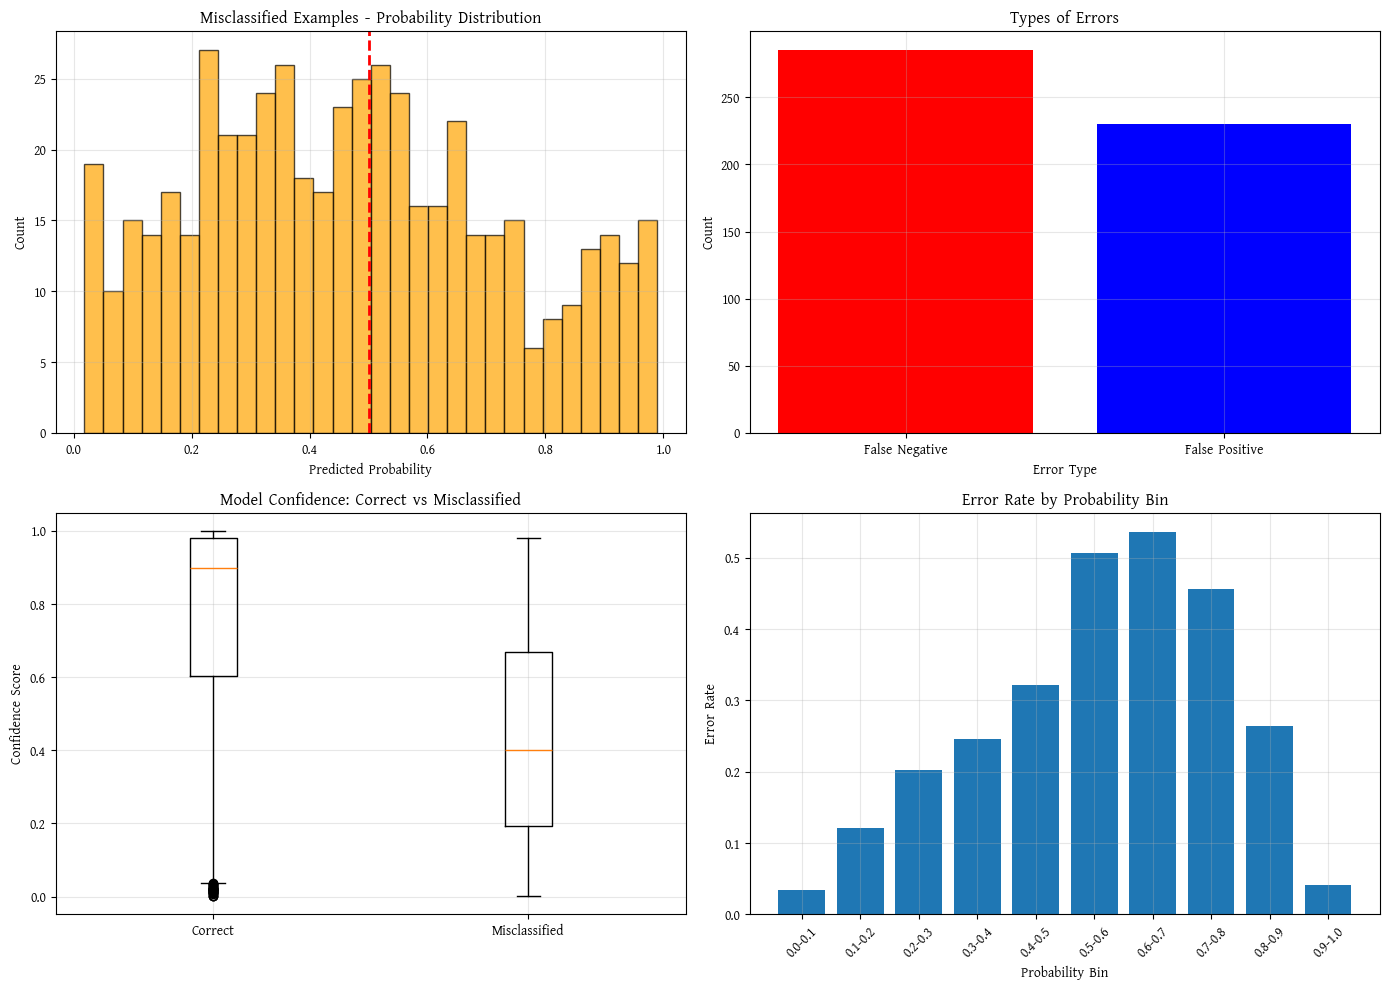

In [61]:
# Find misclassified examples
misclassified_indices = np.where(y_pred != y_test)[0]
correct_indices = np.where(y_pred == y_test)[0]

print(f"Total misclassified: {len(misclassified_indices)}")
print(f"Total correct: {len(correct_indices)}")

# Sample misclassified examples with their probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Probability distribution of misclassified
axes[0].hist(y_prob[misclassified_indices], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Misclassified Examples - Probability Distribution')
axes[0].grid(True, alpha=0.3)

# Plot 2: Error types
error_types = []
for pred, true in zip(y_pred[misclassified_indices], y_test[misclassified_indices]):
    if pred == 0 and true == 1:
        error_types.append('False Negative')
    elif pred == 1 and true == 0:
        error_types.append('False Positive')

error_counts = pd.Series(error_types).value_counts()
axes[1].bar(error_counts.index, error_counts.values, color=['red', 'blue'])
axes[1].set_xlabel('Error Type')
axes[1].set_ylabel('Count')
axes[1].set_title('Types of Errors')
axes[1].grid(True, alpha=0.3)

# Plot 3: Confidence vs Error
confidence = np.abs(y_prob - 0.5) * 2  # 0 = uncertain, 1 = certain
axes[2].boxplot([confidence[y_pred == y_test], confidence[y_pred != y_test]], 
                labels=['Correct', 'Misclassified'])
axes[2].set_ylabel('Confidence Score')
axes[2].set_title('Model Confidence: Correct vs Misclassified')
axes[2].grid(True, alpha=0.3)

# Plot 4: Error distribution by probability bins
bins = np.linspace(0, 1, 11)
error_rate = []
for i in range(len(bins)-1):
    mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
    if np.sum(mask) > 0:
        error_rate.append(np.mean(y_pred[mask] != y_test[mask]))
    else:
        error_rate.append(0)

axes[3].bar(range(len(error_rate)), error_rate, tick_label=[f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)])
axes[3].set_xlabel('Probability Bin')
axes[3].set_ylabel('Error Rate')
axes[3].set_title('Error Rate by Probability Bin')
axes[3].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
# If using a model with feature importance
if hasattr(best_model, 'feature_importances_'):
    # For tree-based models
    importances = best_model.feature_importances_
    
    # Get top features
    if hasattr(best_model, 'feature_names_in_'):
        feature_names = best_model.feature_names_in_
    else:
        feature_names = [f'Feature_{i}' for i in range(len(importances))]
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(20)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    ax.set_title('Top 20 Feature Importances')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

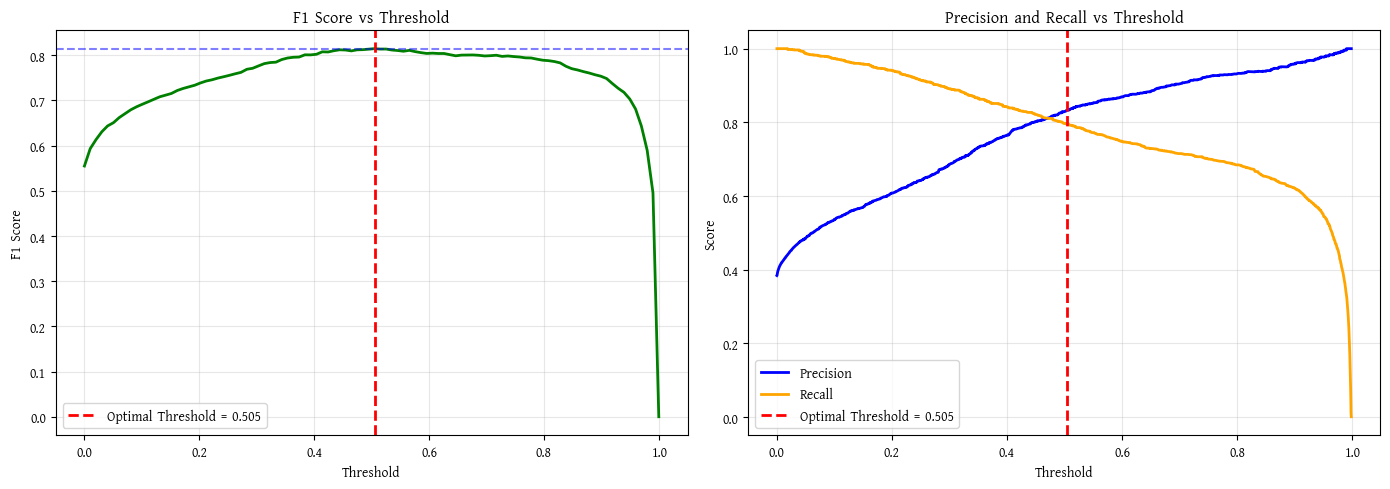

Optimal threshold: 0.505
Best F1 Score: 0.815


In [63]:
from sklearn.metrics import precision_recall_curve, f1_score

# Find optimal threshold
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 Score vs Threshold
axes[0].plot(thresholds, f1_scores, linewidth=2, color='green')
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
axes[0].axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Optimal Threshold = {optimal_threshold:.3f}')
axes[0].axhline(y=max(f1_scores), color='blue', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision and Recall vs Threshold
axes[1].plot(pr_thresholds, precision[:-1], linewidth=2, label='Precision', color='blue')
axes[1].plot(pr_thresholds, recall[:-1], linewidth=2, label='Recall', color='orange')
axes[1].axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Optimal Threshold = {optimal_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision and Recall vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Best F1 Score: {max(f1_scores):.3f}")

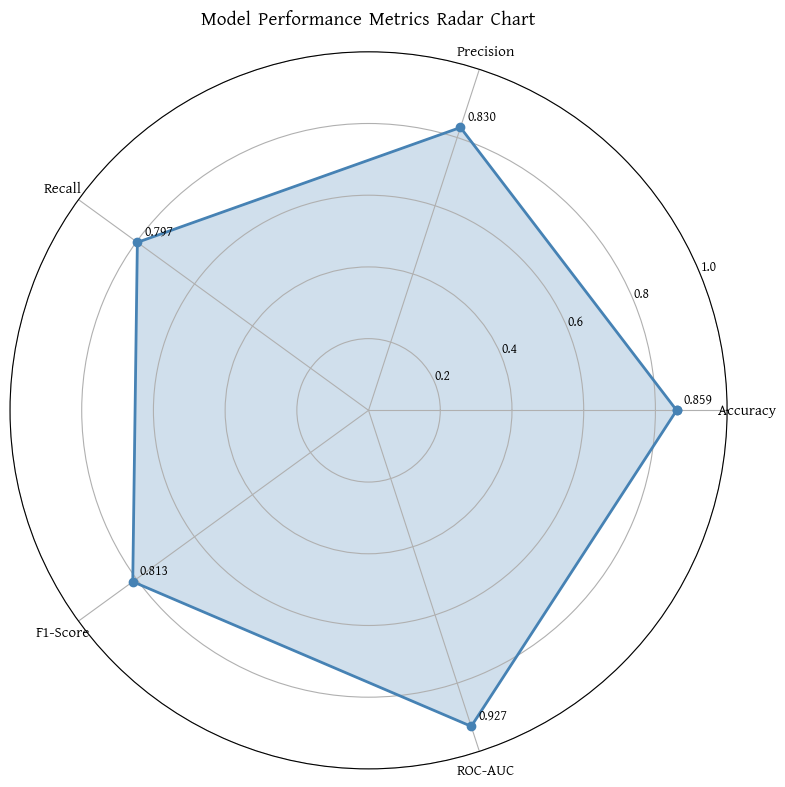

In [64]:
# Calculate metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

# Radar Chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

categories = list(metrics.keys())
values = list(metrics.values())

# Complete the loop
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax.plot(angles, values, 'o-', linewidth=2, color='steelblue')
ax.fill(angles, values, alpha=0.25, color='steelblue')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Metrics Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.grid(True)

# Add values as annotations
for angle, value, category in zip(angles[:-1], values[:-1], categories):
    ax.annotate(f'{value:.3f}', xy=(angle, value), xytext=(5, 5), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

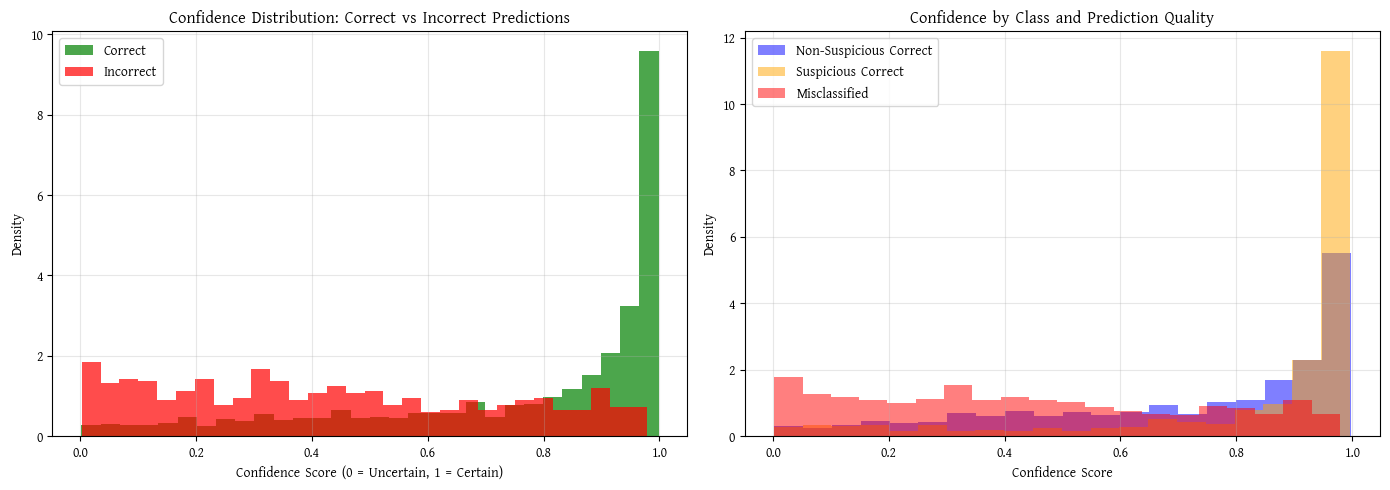

In [65]:
# Confidence analysis
confidence = np.abs(y_prob - 0.5) * 2  # Scale to 0-1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution
axes[0].hist(confidence[y_pred == y_test], bins=30, alpha=0.7, color='green', label='Correct', density=True)
axes[0].hist(confidence[y_pred != y_test], bins=30, alpha=0.7, color='red', label='Incorrect', density=True)
axes[0].set_xlabel('Confidence Score (0 = Uncertain, 1 = Certain)')
axes[0].set_ylabel('Density')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confidence by actual class
correct_class0 = (y_test == 0) & (y_pred == y_test)
correct_class1 = (y_test == 1) & (y_pred == y_test)

axes[1].hist(confidence[correct_class0], bins=20, alpha=0.5, color='blue', label='Non-Suspicious Correct', density=True)
axes[1].hist(confidence[correct_class1], bins=20, alpha=0.5, color='orange', label='Suspicious Correct', density=True)
axes[1].hist(confidence[y_pred != y_test], bins=20, alpha=0.5, color='red', label='Misclassified', density=True)
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Confidence by Class and Prediction Quality')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

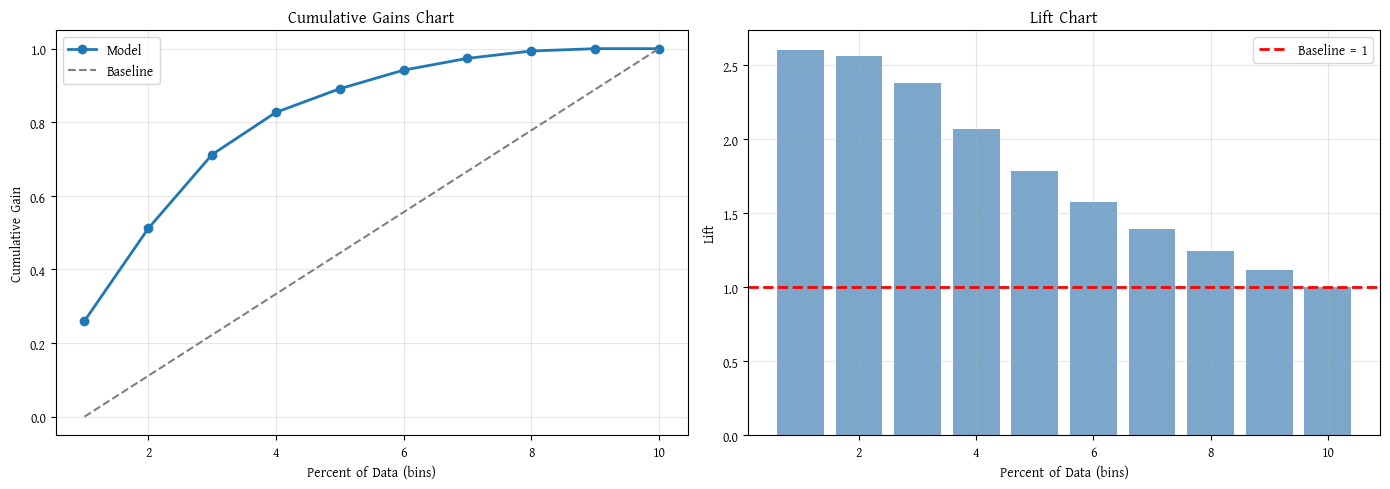

In [66]:
# Cumulative Gains and Lift Chart
def plot_gain_lift(y_true, y_prob, n_bins=10):
    # Sort by probability
    sorted_indices = np.argsort(y_prob)[::-1]
    y_true_sorted = y_true[sorted_indices]
    y_prob_sorted = y_prob[sorted_indices]
    
    # Create bins
    n_samples = len(y_true_sorted)
    bin_size = n_samples // n_bins
    
    cumulative_gain = []
    lift = []
    
    for i in range(1, n_bins + 1):
        n_selected = i * bin_size
        n_positives_selected = np.sum(y_true_sorted[:n_selected])
        n_positives_total = np.sum(y_true)
        
        cumulative_gain.append(n_positives_selected / n_positives_total)
        lift.append((n_positives_selected / n_selected) / (n_positives_total / n_samples))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cumulative Gains
    axes[0].plot(range(1, n_bins + 1), cumulative_gain, marker='o', linewidth=2, label='Model')
    axes[0].plot(range(1, n_bins + 1), np.linspace(0, 1, n_bins), '--', color='gray', label='Baseline')
    axes[0].set_xlabel('Percent of Data (bins)')
    axes[0].set_ylabel('Cumulative Gain')
    axes[0].set_title('Cumulative Gains Chart')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Lift Chart
    axes[1].bar(range(1, n_bins + 1), lift, color='steelblue', alpha=0.7)
    axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline = 1')
    axes[1].set_xlabel('Percent of Data (bins)')
    axes[1].set_ylabel('Lift')
    axes[1].set_title('Lift Chart')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_gain_lift(y_test, y_prob)

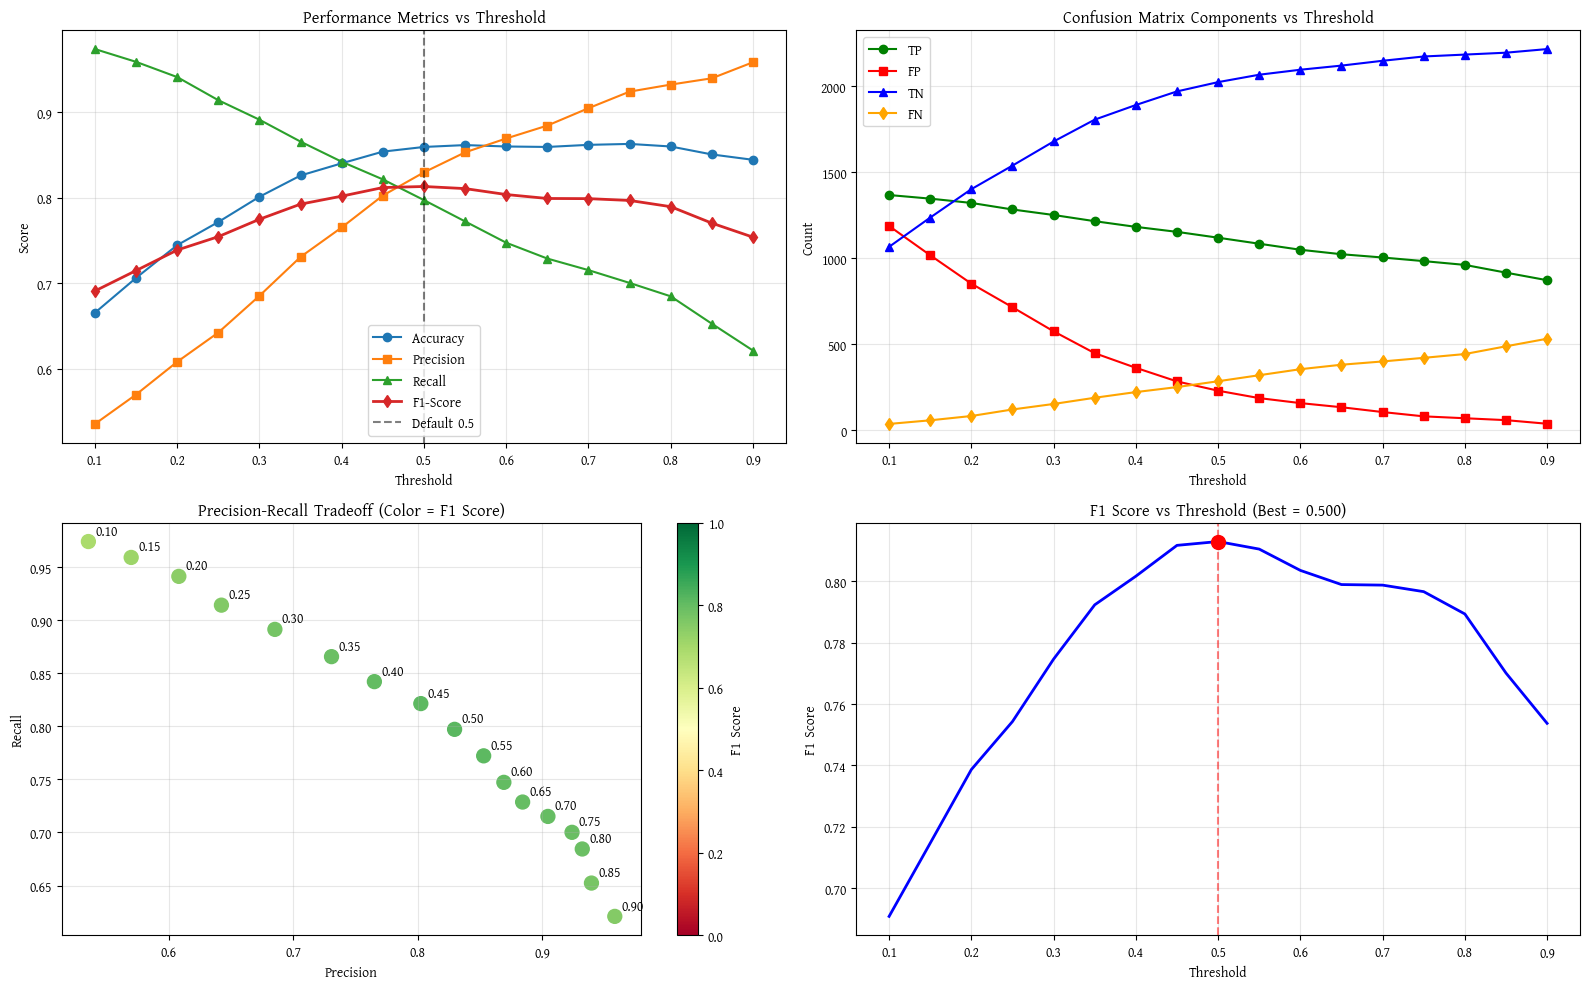

In [67]:
# Comprehensive threshold analysis
thresholds = np.linspace(0.1, 0.9, 17)
metrics_at_threshold = {
    'Threshold': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1': [],
    'TP': [],
    'FP': [],
    'TN': [],
    'FN': []
}

for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    metrics_at_threshold['Threshold'].append(t)
    metrics_at_threshold['Accuracy'].append(accuracy_score(y_test, pred))
    metrics_at_threshold['Precision'].append(precision_score(y_test, pred, zero_division=0))
    metrics_at_threshold['Recall'].append(recall_score(y_test, pred))
    metrics_at_threshold['F1'].append(f1_score(y_test, pred))
    metrics_at_threshold['TP'].append(tp)
    metrics_at_threshold['FP'].append(fp)
    metrics_at_threshold['TN'].append(tn)
    metrics_at_threshold['FN'].append(fn)

metrics_df = pd.DataFrame(metrics_at_threshold)

# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Metrics vs Threshold
axes[0, 0].plot(metrics_df['Threshold'], metrics_df['Accuracy'], label='Accuracy', marker='o')
axes[0, 0].plot(metrics_df['Threshold'], metrics_df['Precision'], label='Precision', marker='s')
axes[0, 0].plot(metrics_df['Threshold'], metrics_df['Recall'], label='Recall', marker='^')
axes[0, 0].plot(metrics_df['Threshold'], metrics_df['F1'], label='F1-Score', marker='d', linewidth=2)
axes[0, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default 0.5')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Performance Metrics vs Threshold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# TP, FP, TN, FN counts
axes[0, 1].plot(metrics_df['Threshold'], metrics_df['TP'], label='TP', marker='o', color='green')
axes[0, 1].plot(metrics_df['Threshold'], metrics_df['FP'], label='FP', marker='s', color='red')
axes[0, 1].plot(metrics_df['Threshold'], metrics_df['TN'], label='TN', marker='^', color='blue')
axes[0, 1].plot(metrics_df['Threshold'], metrics_df['FN'], label='FN', marker='d', color='orange')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Confusion Matrix Components vs Threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score heatmap across precision-recall tradeoff
axes[1, 0].scatter(metrics_df['Precision'], metrics_df['Recall'], 
                   c=metrics_df['F1'], s=100, cmap='RdYlGn', vmin=0, vmax=1)
for i, row in metrics_df.iterrows():
    axes[1, 0].annotate(f"{row['Threshold']:.2f}", (row['Precision'], row['Recall']), 
                        xytext=(5, 5), textcoords='offset points')
axes[1, 0].set_xlabel('Precision')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Precision-Recall Tradeoff (Color = F1 Score)')
axes[1, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('F1 Score')

# Best threshold region
axes[1, 1].plot(metrics_df['Threshold'], metrics_df['F1'], color='blue', linewidth=2)
best_idx = metrics_df['F1'].idxmax()
best_threshold = metrics_df.loc[best_idx, 'Threshold']
best_f1 = metrics_df.loc[best_idx, 'F1']
axes[1, 1].scatter(best_threshold, best_f1, color='red', s=100, zorder=5)
axes[1, 1].axvline(x=best_threshold, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title(f'F1 Score vs Threshold (Best = {best_threshold:.3f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

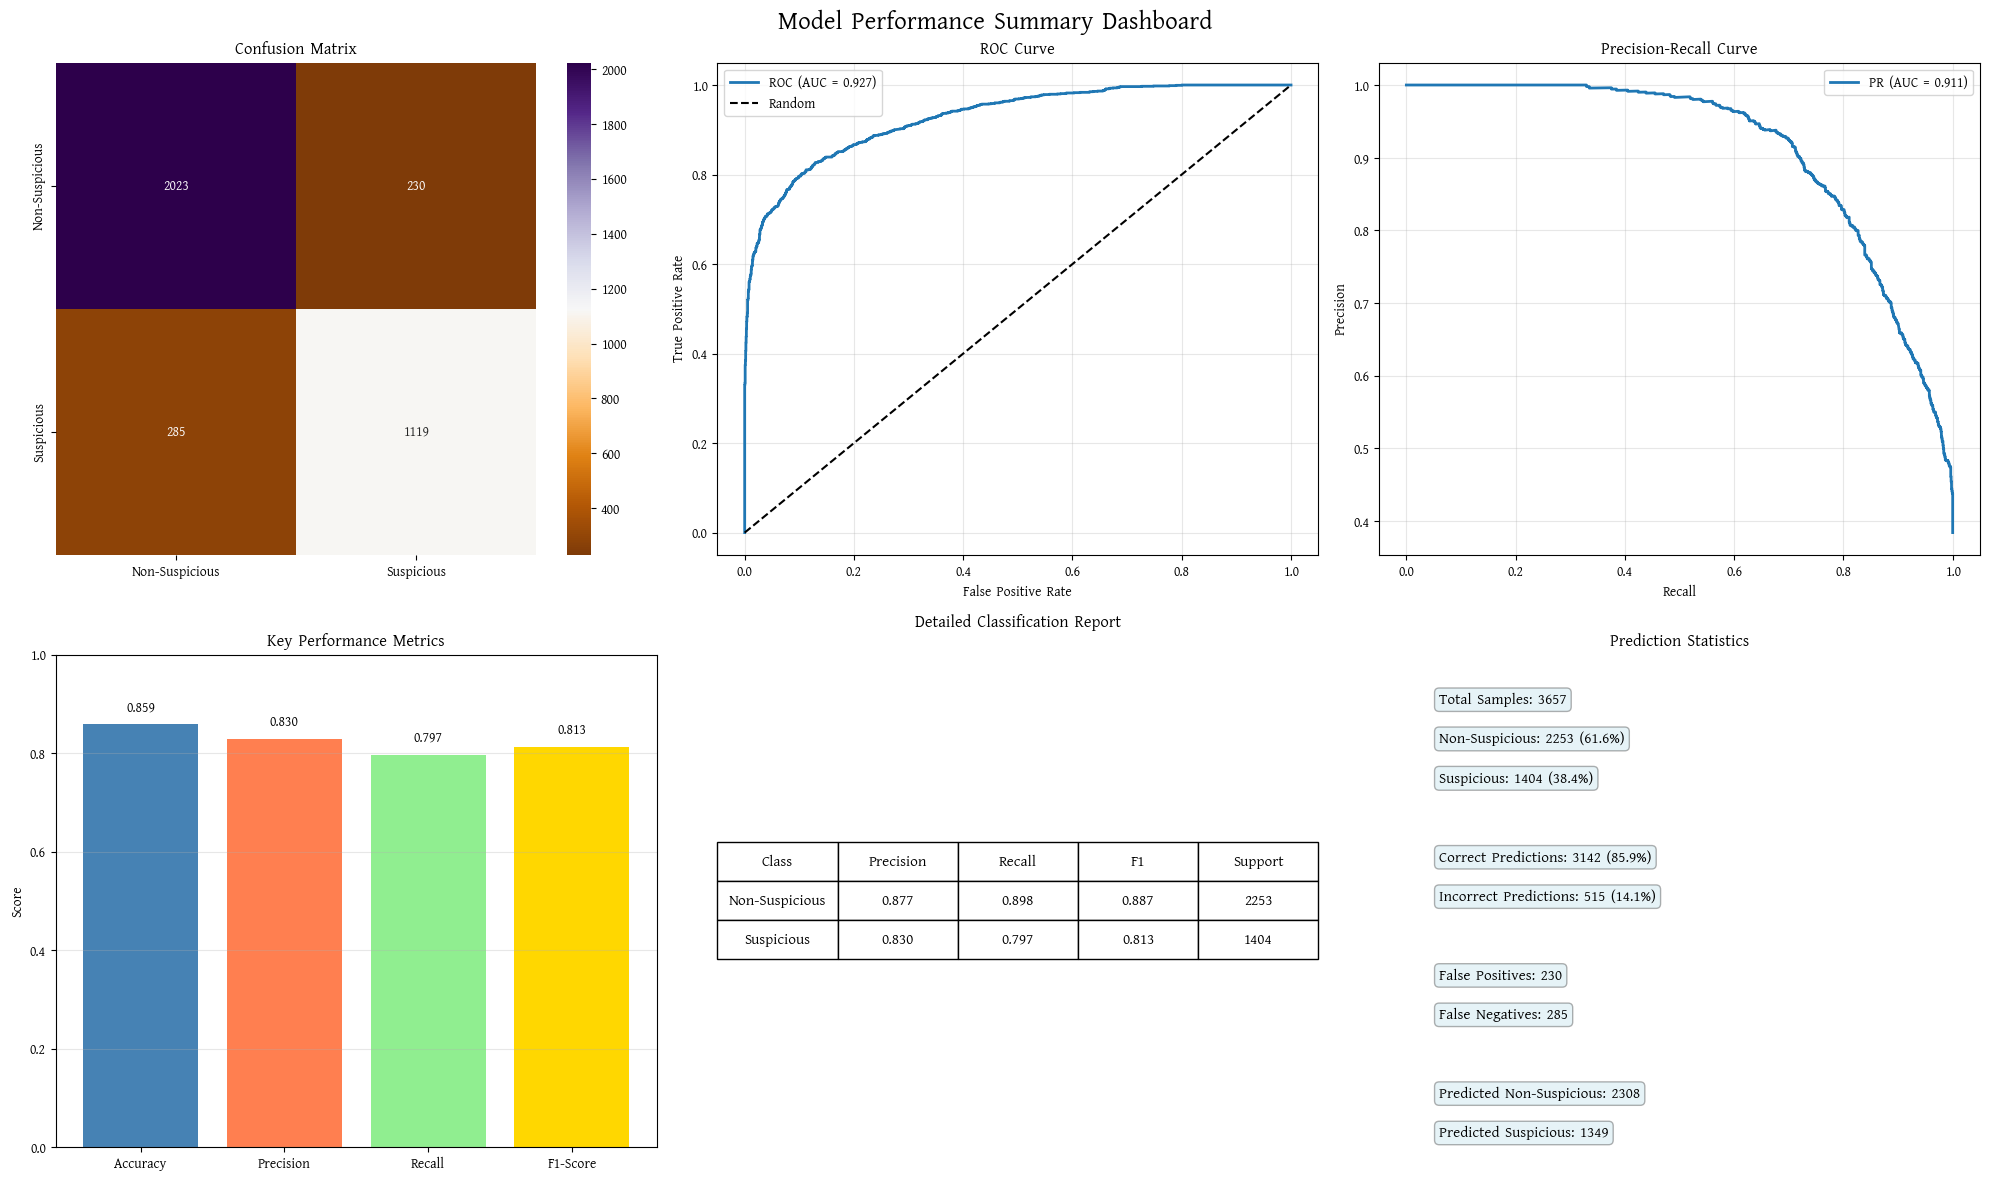

In [68]:
# Comprehensive model summary
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Model Performance Summary Dashboard', fontsize=18, fontweight='bold')

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='PuOr',
            xticklabels=['Non-Suspicious', 'Suspicious'],
            yticklabels=['Non-Suspicious', 'Suspicious'], ax=ax1)
ax1.set_title('Confusion Matrix')

# 2. ROC Curve (if not already plotted)
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = plt.subplot(2, 3, 3)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
ax3.plot(recall, precision, linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Key Metrics Bar Chart
ax4 = plt.subplot(2, 3, 4)
metrics_dict = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}
bars = ax4.bar(metrics_dict.keys(), metrics_dict.values(), 
               color=['steelblue', 'coral', 'lightgreen', 'gold'])
ax4.set_ylim(0, 1)
ax4.set_ylabel('Score')
ax4.set_title('Key Performance Metrics')
ax4.grid(True, alpha=0.3, axis='y')
for bar, value in zip(bars, metrics_dict.values()):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{value:.3f}', ha='center', va='bottom', fontsize=10)

# 5. Classification Report Table
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')
report_dict = classification_report(y_test, y_pred, 
                                    target_names=['Non-Suspicious', 'Suspicious'],
                                    output_dict=True)
table_data = []
for label in ['Non-Suspicious', 'Suspicious']:
    table_data.append([
        label,
        f"{report_dict[label]['precision']:.3f}",
        f"{report_dict[label]['recall']:.3f}",
        f"{report_dict[label]['f1-score']:.3f}",
        f"{report_dict[label]['support']:.0f}"
    ])
table = ax5.table(cellText=table_data,
                 colLabels=['Class', 'Precision', 'Recall', 'F1', 'Support'],
                 loc='center',
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
ax5.set_title('Detailed Classification Report', pad=20)

# 6. Prediction Stats
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
stats_text = [
    f"Total Samples: {len(y_test)}",
    f"Non-Suspicious: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.1f}%)",
    f"Suspicious: {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.1f}%)",
    "",
    f"Correct Predictions: {sum(y_pred == y_test)} ({accuracy_score(y_test, y_pred)*100:.1f}%)",
    f"Incorrect Predictions: {sum(y_pred != y_test)} ({(1-accuracy_score(y_test, y_pred))*100:.1f}%)",
    "",
    f"False Positives: {np.sum((y_pred == 1) & (y_test == 0))}",
    f"False Negatives: {np.sum((y_pred == 0) & (y_test == 1))}",
    "",
    f"Predicted Non-Suspicious: {sum(y_pred == 0)}",
    f"Predicted Suspicious: {sum(y_pred == 1)}"
]
for i, text in enumerate(stats_text):
    ax6.text(0.1, 0.9 - i*0.08, text, fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax6.set_title('Prediction Statistics')

plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# Cell Classification Report
# ============================================================

# Generate the classification report
# Target names match the labels used in the confusion matrix
report = classification_report(y_test, y_pred, target_names=["Non-Suspicious", "Suspicious"])

# Display the report
print("Classification Report:\n")
print(report)

Classification Report:

                precision    recall  f1-score   support

Non-Suspicious       0.88      0.90      0.89      2253
    Suspicious       0.83      0.80      0.81      1404

      accuracy                           0.86      3657
     macro avg       0.85      0.85      0.85      3657
  weighted avg       0.86      0.86      0.86      3657



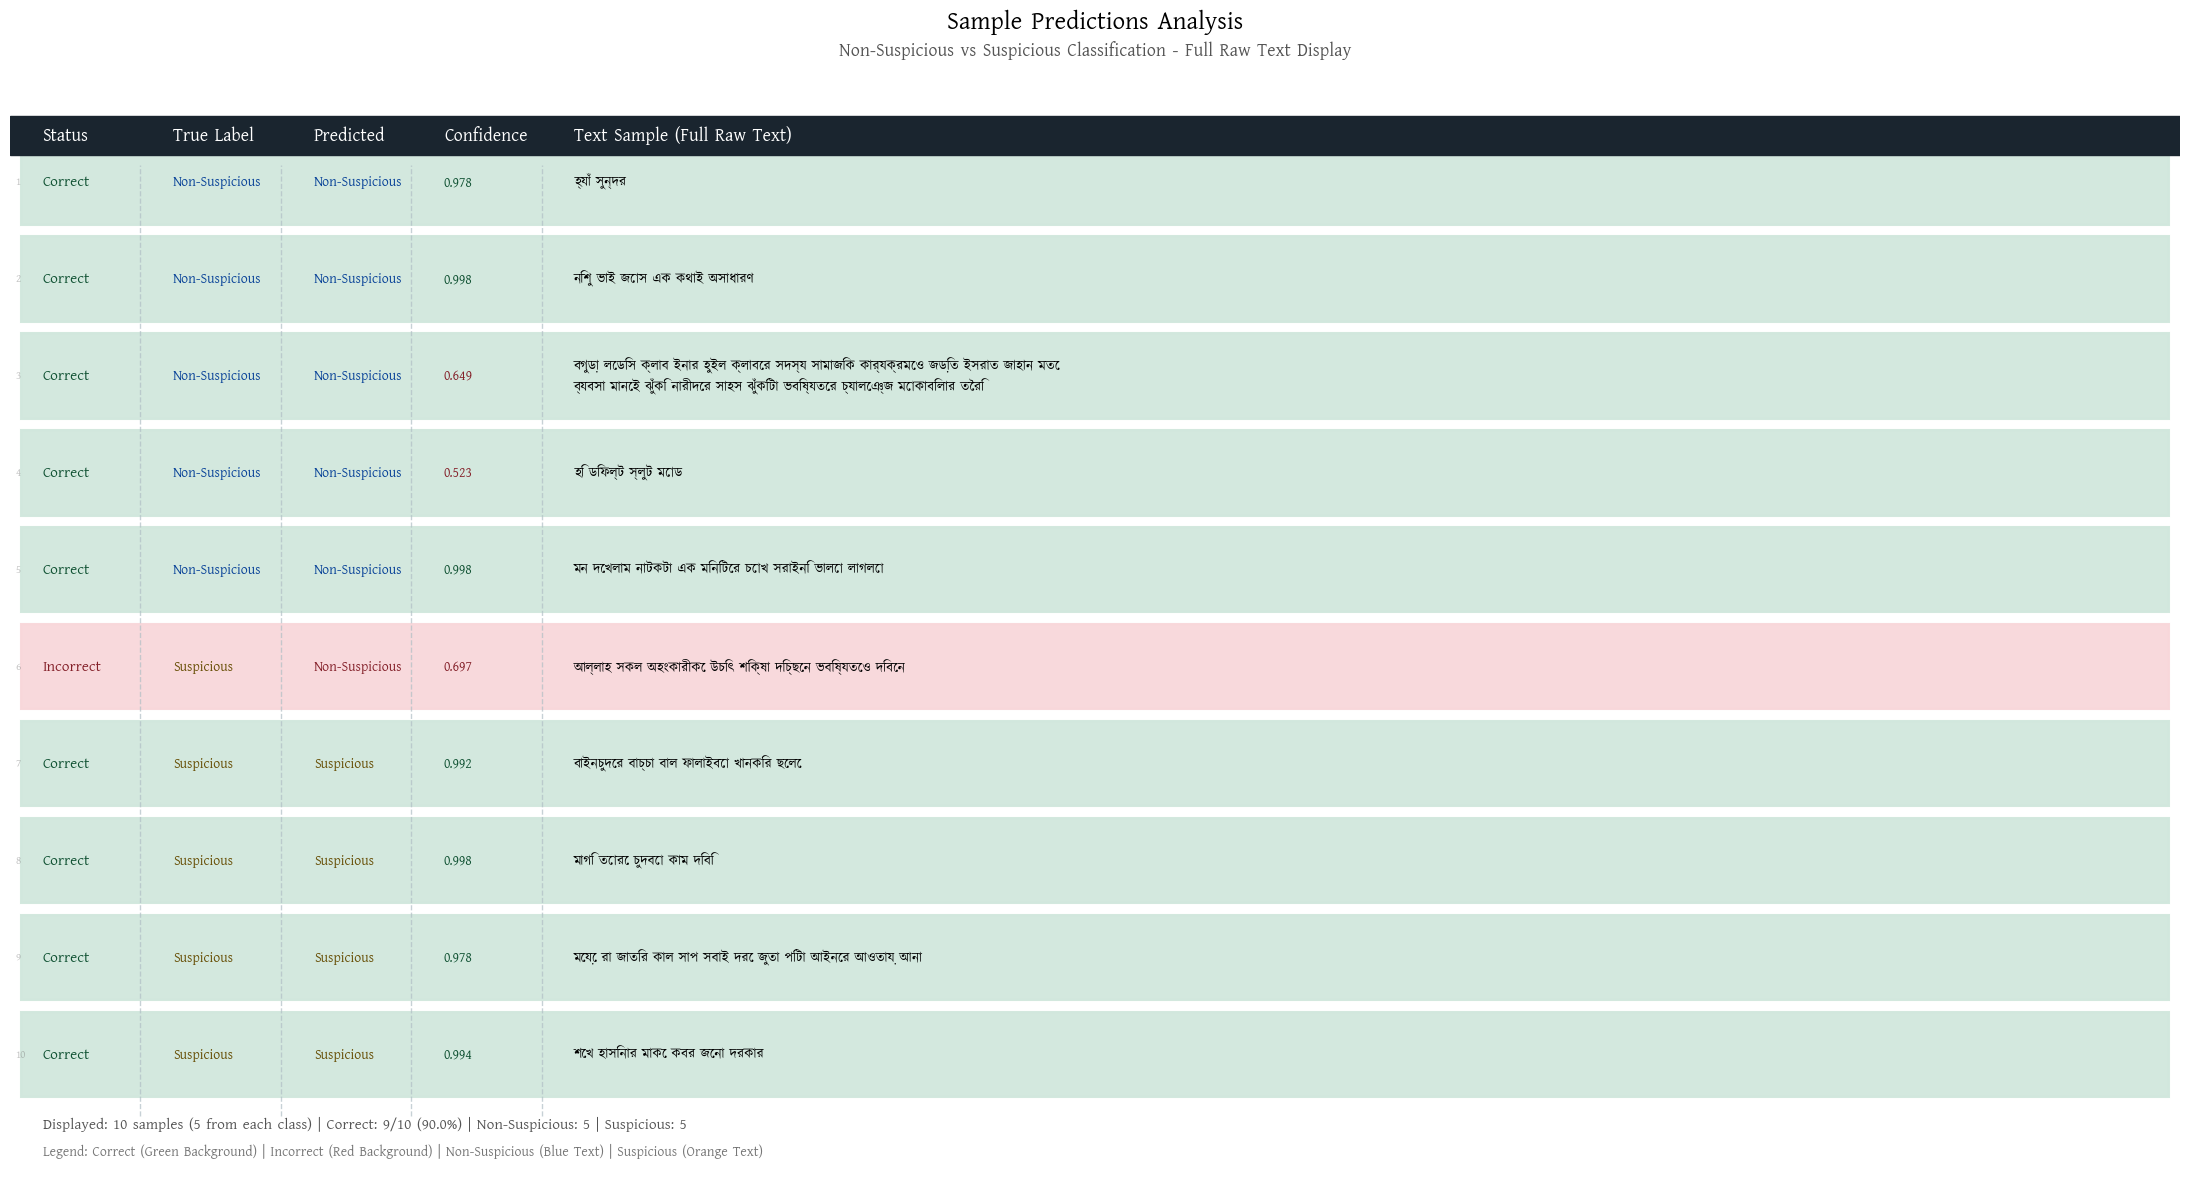

In [70]:
# ============================================================
# Cell Sample Predictions with Full Raw Text Display - Professional Design
# ============================================================


# Prepare confidence scores
y_prob_flat = y_prob.flatten() if len(y_prob.shape) > 1 else y_prob
confidence = np.where(y_pred == 1, y_prob_flat, 1 - y_prob_flat)

# Create dataframe using X_test directly
df_check = pd.DataFrame({
    "True Label": y_test,
    "Predicted Label": y_pred,
    "Confidence": confidence,
    "Text": X_test
})
df_check["Correct"] = df_check["True Label"] == df_check["Predicted Label"]

# Sample 5 from each class
fake_sample = df_check[df_check["True Label"] == 0].sample(min(5, len(df_check[df_check["True Label"] == 0])), random_state=42)
real_sample = df_check[df_check["True Label"] == 1].sample(min(5, len(df_check[df_check["True Label"] == 1])), random_state=42)
display_df = pd.concat([fake_sample, real_sample]).reset_index(drop=True)

label_name = {0: "Non-Suspicious", 1: "Suspicious"}

# Create professional visualization (Reduced overall figure height)
fig, ax = plt.subplots(figsize=(22, 12))
ax.axis("off")

# Define clean column positions
col_positions = {
    "status": 0.3,
    "true": 1.5,
    "pred": 2.8,
    "conf": 4.0,
    "text": 5.2
}

# Row height and spacing
row_height = 2.2
spacing = row_height + 0.3

# Draw header background
header_y = len(display_df) * spacing + 1.2
ax.add_patch(plt.Rectangle((0, header_y - 0.5), 20, 1.0, color="#1a252f", zorder=1))

# Clean Headers (No emojis)
headers = [
    ("Status", col_positions["status"], "white"),
    ("True Label", col_positions["true"], "white"),
    ("Predicted", col_positions["pred"], "white"),
    ("Confidence", col_positions["conf"], "white"),
    ("Text Sample (Full Raw Text)", col_positions["text"], "white")
]

for text, x_pos, color in headers:
    ax.text(x_pos, header_y, text, fontsize=13, fontweight="bold", 
            va="center", color=color)

# Draw rows with deeper, high-contrast colors
for i, row in display_df.iterrows():
    y_pos = (len(display_df) - i) * spacing
    
    # Determine deeper, richer colors for high contrast
    if row["Correct"]:
        bg_color = "#d1e7dd"  # Deeper professional green
        border_color = "#0f5132"
        status_color = "#0f5132"
    else:
        bg_color = "#f8d7da"  # Deeper professional red
        border_color = "#842029"
        status_color = "#842029"
    
    # Draw row background
    rect = plt.Rectangle((0.1, y_pos - row_height/2), 19.8, row_height, 
                         color=bg_color, zorder=0, linewidth=1.5, 
                         edgecolor=border_color, alpha=0.95)
    ax.add_patch(rect)
    
    # Add subtle row number
    ax.text(0.05, y_pos, f"{i+1}", fontsize=8, va="center", 
            color="gray", alpha=0.5)
    
    # Status text
    status_text = "Correct" if row["Correct"] else "Incorrect"
    ax.text(col_positions["status"], y_pos, status_text, 
            fontsize=11, va="center", color=status_color, fontweight="bold")
    
    # True Label with color coding
    true_color = "#084298" if row["True Label"] == 0 else "#664d03"
    ax.text(col_positions["true"], y_pos, label_name[row["True Label"]], 
            fontsize=10, va="center", color=true_color, fontweight="bold")
    
    # Predicted Label with color coding
    pred_color = "#084298" if row["Predicted Label"] == 0 else "#664d03"
    if row["True Label"] != row["Predicted Label"]:
        pred_color = "#842029"  # Strong red for wrong predictions
    ax.text(col_positions["pred"], y_pos, label_name[row["Predicted Label"]], 
            fontsize=10, va="center", color=pred_color, fontweight="bold")
    
    # Confidence score
    conf_value = row["Confidence"]
    conf_text = f"{conf_value:.3f}"
    ax.text(col_positions["conf"], y_pos, conf_text, 
            fontsize=10, va="center", fontweight="bold",
            color="#0f5132" if conf_value > 0.8 else "#842029")
    
    # Full text with proper wrapping and Bangla font
    full_text = str(row["Text"])
    wrapped_text = textwrap.fill(full_text, width=90)
    
    ax.text(col_positions["text"], y_pos, wrapped_text, 
            fontsize=10, va="center", fontproperties=font_prop,
            linespacing=1.3, wrap=True)

# Add vertical separator lines for professional structure
separator_x = [1.2, 2.5, 3.7, 4.9]
for x_pos in separator_x:
    ax.axvline(x=x_pos, ymin=0.05, ymax=0.92, color="#b0bec5", 
               linewidth=1, linestyle="--", alpha=0.7, zorder=2)

# Add title with subtitle
plt.suptitle("Sample Predictions Analysis", fontsize=18, fontweight="bold", y=0.98)
plt.title("Non-Suspicious vs Suspicious Classification - Full Raw Text Display", 
          fontsize=13, pad=15, style="italic", color="#555555")

# Add footer with statistics right below the last row
last_row_y = spacing
footer_y = last_row_y - 1.8
total_correct = display_df["Correct"].sum()
total_samples = len(display_df)
accuracy = total_correct/total_samples*100

footer_text = f"Displayed: {total_samples} samples (5 from each class) | "
footer_text += f"Correct: {total_correct}/{total_samples} ({accuracy:.1f}%) | "
footer_text += f"Non-Suspicious: {len(display_df[display_df['True Label']==0])} | "
footer_text += f"Suspicious: {len(display_df[display_df['True Label']==1])}"

ax.text(0.3, footer_y, footer_text, fontsize=11, va="center", 
        color="#555555", style="italic", fontweight="bold")

# Add clean text legend directly beneath footer
legend_text = "Legend: Correct (Green Background) | Incorrect (Red Background) | Non-Suspicious (Blue Text) | Suspicious (Orange Text)"
ax.text(0.3, footer_y - 0.7, legend_text, fontsize=10, va="center", 
        color="#777777", style="italic")

# Set precise axis limits to completely remove whitespace
ax.set_xlim(0, 20)
ax.set_ylim(footer_y - 1.2, header_y + 1.5)

# Adjust layout and display plot tightly
plt.tight_layout()
plt.savefig("sample_predictions_enhanced.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# ============================================================
# Cell Professional Gradio Web Interface for Inference
# ============================================================

def predict_text(text):
    """
    Predicts whether the input text is Suspicious or Non-Suspicious 
    using the trained model and returns formatted results.
    """
    if not text.strip():
        return "Please enter valid text.", "0.00%", "Error"
    
    # Convert raw text into the same integer token sequence format
    # the model was trained on, using the fitted TextVectorization layer.
    input_seq = vectorizer(tf.constant([text])).numpy()
    
    # Run inference
    prob = best_model.predict(input_seq, verbose=0)[0][0]
    prob = float(prob)
        
    # Determine prediction and confidence
    is_suspicious = prob >= 0.50
    label = "Suspicious" if is_suspicious else "Non-Suspicious"
    confidence = prob if is_suspicious else (1 - prob)
    
    # Color-coded badge styling for UI output
    if is_suspicious:
        badge = f"<span style='color: #842029; background-color: #f8d7da; padding: 6px 12px; border-radius: 6px; font-weight: bold;'>Suspicious</span>"
    else:
        badge = f"<span style='color: #0f5132; background-color: #d1e7dd; padding: 6px 12px; border-radius: 6px; font-weight: bold;'>Non-Suspicious</span>"
        
    conf_str = f"{confidence * 100:.2f}%"
    
    return badge, conf_str, label

# Build clean, modern Gradio Blocks interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # Content Moderation & Suspicion Detection System
        Enter a sentence or text snippet below to analyze its classification status in real-time.
        """
    )
    
    with gr.Row():
        with gr.Column(scale=2):
            input_text = gr.Textbox(
                label="Input Text",
                placeholder="Type or paste your text here (supports Bangla and English)...",
                lines=5
            )
            submit_btn = gr.Button("Analyze Text", variant="primary")
            
        with gr.Column(scale=1):
            output_status = gr.HTML(label="Prediction Result")
            output_conf = gr.Textbox(label="Confidence Score")
            output_label = gr.Textbox(label="Detected Class")

    # Comprehensive collection of benchmark and evaluation examples (Bangla)
    gr.Examples(
        examples=[
            ["নাটক টা হয়তোবা আবার নাটকে নিশো ভাই বছরের সেরা হতো"], # 0 (Non-Suspicious)
            ["মাখি তোর হেডা বাশ দিমু"], # 1 (Suspicious/Slang)
            ["সবাই মিলে আজ বনভোজনে যাচ্ছি, অনেক মজা হবে।"], # 0 (Non-Suspicious)
            ["মুখে লাগাম কথা বলবেন কথা বলছেন সাধ্য কারো করেনি কেয়ামত পারবে ইসলাম ধর্ম সম্পর্কে বেহুদা কথা বলার সৃষ্টির্তাকে ভয় করুন"], # 1 (Suspicious/Aggressive)
            ["আগামীকাল আমাদের অফিস মিটিং সকাল ১০ টায়।"], # 0 (Non-Suspicious)
            ["তোর চৌদ্দ গুষ্টি উদ্ধার করে দেবো শুয়োরের বাচ্চা"], # 1 (Suspicious/Slang)
            ["আজ আবহাওয়া খুব সুন্দর, বাইরে ঘুরতে যেতে ইচ্ছা করছে।"], # 0 (Non-Suspicious)
            ["তোদের সবাইকে শেষ করে দেবো আজ, তোদের রক্ষা নেই"], # 1 (Suspicious/Threat)
            ["পড়াশোনা নিয়ে একটু সিরিয়াস হওয়া দরকার সবার।"], # 0 (Non-Suspicious)
            ["মাদারজাত তোর এত বড় আস্পর্দা তুই আমার সাথে এমন করিস"], # 1 (Suspicious/Slang)
            ["সঠিক আপনাকে অভিশাপ চাই এমনকি বুঝতে নি বলেছিলেন অস্তিত্ব"], # 1 (Suspicious/Curse)
            ["আরে ভাই নিজেকে কখনো বড় দাবি পৃথিবীতে সবাই সমান"]  # 0 (Non-Suspicious)
        ],
        inputs=input_text
    )

    submit_btn.click(
        fn=predict_text,
        inputs=[input_text],
        outputs=[output_status, output_conf, output_label]
    )
    
    input_text.submit(
        fn=predict_text, 
        inputs=[input_text], 
        outputs=[output_status, output_conf, output_label]
    )

demo.launch(inline=True, share=True, debug=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://df1e8d1cb13ab4757a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
